In [1]:
# @title
import pandas as pd
from google.colab import drive
import h5py
import numpy as np
import warnings
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
drive.mount('/content/drive')

# Load the CSV
df = pd.read_csv('/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Final_Project/Cell-Table-S26.xlsx - Master.csv')

# Build a dict: { cell_id: [list of C60 cycles values] }

cell_c60 = {}
c60_3 = {}
c60_5 = {}
c60_6 = {}
R2_THRESHOLD = 0.85
i = 0
j = 0
k = 0

for _, row in df.iterrows():
    cell_id = row['Cell']
    c60 = row['C60 cycles']
    if pd.notna(cell_id) and pd.notna(c60):
        try:
            cell_c60[cell_id] = int(c60)
        except ValueError:
            print(f"Skipping {cell_id}: invalid value '{c60}'")

for cell in cell_c60:
  if cell_c60[cell] == 3:
    c60_3[i] = cell
    i = i + 1
  elif cell_c60[cell] == 5:
    c60_5[j] = cell
    j = j + 1
  elif cell_c60[cell] == 6:
    c60_6[k] = cell
    k = k + 1

Mounted at /content/drive
Skipping A01: invalid value 'Unknown'


The next two functions are used to compute both the series resistance and the shunt resistance, followed  by a function used to plot both types of resistance related to time.

In [2]:
# @title
# ============================================================
# FUNCTION — compute_shunt
# ============================================================

def compute_shunt(V, J):

    """
    Fits a linear regression to the shunt region (near V=0)
    and returns shunt resistance as dV/dJ (slope of V vs J).

    Parameters:
        V : array of voltage values (shunt region)
        J : array of current density values (shunt region)

    Returns:
        Rsh : scalar shunt resistance value
    """

    coeffs = np.polyfit(J, V, 1)
    Rsh = coeffs[0]
    return Rsh

In [3]:
# @title
# ============================================================
# FUNCTION — compute_series
# ============================================================

def compute_series(V_s, J_s):

    """
    Fits a linear regression to the series region (near J=0)
    and returns series resistance as dV/dJ (slope of V vs J).

    Parameters:
        V_s : array of voltage values (series region)
        J_s : array of current density values (series region)

    Returns:
        Rs : scalar series resistance value
    """

    coeffs = np.polyfit(J_s, V_s, 1)
    Rs = coeffs[0]
    return Rs

In [4]:
# @title
# ============================================================
# FUNCTION — plot_resistance
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_resistance(results, num_weeks, resistance_type):

    """
    Plots average resistance over time for each C60 cycle.
    One data point per week, one line per cycle, with error bars.

    Parameters:
        results        : dict structured as results[cycle][week_idx]
                         = [shunt_avg, series_avg, shunt_std, series_std]
        num_weeks      : total number of weeks (int)
        resistance_type: "shunt" or "series"
    """

    # Map resistance type to index in results list
    if resistance_type == "shunt":
        avg_idx   = 0
        std_idx   = 2
        count_idx = 4
        title     = "Shunt Resistance"
        ylabel    = "Resistance (kΩ)"
    elif resistance_type == "series":
        avg_idx   = 1
        std_idx   = 3
        count_idx = 5
        title     = "Series Resistance"
        ylabel    = "Resistance (kΩ)"
    else:
        raise ValueError(f"resistance_type must be 'shunt' or 'series', got '{resistance_type}'")

    # X axis — 1-indexed week numbers
    week_numbers = [5.5, 7, 8, 9, 10, 11, 13] #CHANGED#

    # Cycle display settings
    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60 3"},
        5: {"color": "tab:orange", "label": "C60 5"},
        6: {"color": "tab:green",  "label": "C60 6"},
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for cycle, style in cycle_styles.items():
        avgs = []
        stds = []

        for week_idx in range(num_weeks):
          if week_idx not in results[cycle]:
              avgs.append(np.nan)
              stds.append(np.nan)
          else:
              std   = results[cycle][week_idx][std_idx]
              count = results[cycle][week_idx][count_idx]
              avgs.append(results[cycle][week_idx][avg_idx])
              stds.append(std / np.sqrt(count))

        ax.errorbar(
            week_numbers,
            avgs,
            yerr=stds,
            label=style["label"],
            color=style["color"],
            marker="o",
            capsize=4,
            linewidth=1.5,
        )

        # =========================
        # TREND LINE
        # =========================

        y = np.array(avgs)
        x = np.array(week_numbers)

        # Mask invalid (NaN) values automatically
        y_masked = np.ma.masked_invalid(y)

        if y_masked.count() > 1:  # number of valid points
            coeffs = np.polyfit(x[y_masked.mask == False],
                                y_masked.compressed(), 1)
            trend = np.poly1d(coeffs)

            ax.plot(
                x,
                trend(x),
                linestyle="-",
                color=style["color"],
                alpha=0.6,
                label=f"{style['label']} (slope={coeffs[0]:.2e})"
            )

    ax.set_title(title)
    ax.set_xlabel("Calendar Week")
    ax.set_ylabel(ylabel)
    ax.set_xticks(week_numbers)
    ax.legend(title="C60 Cycle")
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()

The iterative sigma clipping function is a statistical outlier removal tool used to clean resistance and fill factor data before averaging and regression analysis. It works by repeatedly computing the mean and standard deviation of a dataset, removing any values that fall outside n standard deviations from the mean, and then recomputing on the remaining data until no further values are removed. This iterative approach is necessary because removing extreme outliers changes the mean and standard deviation of the remaining data, which can expose additional outliers that were not detectable in the presence of the original extreme values. A threshold of 3.5 standard deviations was selected based on diagnostic preview analysis, which confirmed that this value removes only genuinely anomalous measurements while preserving the natural cell-to-cell variability inherent in the dataset.

In [5]:
# ============================================================
# FUNCTION — iterative_sigma_clip
# ============================================================

def iterative_sigma_clip(values, n_sigma):
    """
    Performs iterative sigma clipping on a list of values.
    Repeatedly removes values outside n_sigma standard deviations
    from the mean until no more values are removed.

    Parameters:
        values  : list or array of numeric values
        n_sigma : number of standard deviations to use as threshold

    Returns:
        arr       : cleaned numpy array with outliers removed
        n_removed : number of values removed
    """
    arr = np.array(values, dtype=float)
    while True:
        mean  = np.mean(arr)
        sigma = np.std(arr)
        mask  = np.abs(arr - mean) <= n_sigma * sigma
        if mask.sum() == len(arr):
            break
        arr = arr[mask]
    return arr, len(values) - len(arr)

The following functions are simply the functions provided to the class within the ResearchProject.ipynb

In [6]:
# @title
# ============================================================
# FUNCTIONS GIVEN TO US
# ============================================================

# ============================================================
# HELPER — FORMAT CELL ID
# ============================================================

def _cell_group(cell):
    """Convert a cell identifier to its HDF5 group name.
    Examples: 'A03' -> 'CellA03', 'R27' -> 'CellR27'
    """
    return f"Cell{str(cell).upper()}"


# ============================================================
# FUNCTION — convert_iv_to_jv
# ============================================================

def convert_iv_to_jv(iv_data, area=0.14):
    """
    Convert IV data (mA) to JV data (mA/cm^2).

    Parameters:
        iv_data : pd.DataFrame with 'Forward_mean (mA)' and 'Voltage (V)'
        area    : active pixel area in cm^2 (default 0.14)

    Returns:
        pd.DataFrame with 'Voltage (V)' and 'Forward Scan (mA/cm^2)'
    """
    iv_data = iv_data.copy()
    iv_data['Forward Scan (mA/cm^2)'] = iv_data['Forward_mean (mA)'] / area
    jv_data = iv_data[['Voltage (V)', 'Forward Scan (mA/cm^2)']].copy()
    return jv_data


# ============================================================
# FUNCTION — calculate_jsc
# ============================================================

def calculate_jsc(jv_data, scan_type='Forward Scan (mA/cm^2)'):
    """
    Calculate Short Circuit Current Density (Jsc).
    Jsc is the current density at V = 0.

    Parameters:
        jv_data   : pd.DataFrame with 'Voltage (V)' and scan_type columns
        scan_type : column name for current density

    Returns:
        float : Jsc in mA/cm^2
    """
    jsc_index = jv_data.index[jv_data['Voltage (V)'] == 0]
    if len(jsc_index) == 0:
        return np.nan
    return abs(jv_data.loc[jsc_index, scan_type].values[0])


# ============================================================
# FUNCTION — calculate_voc
# ============================================================

def calculate_voc(jv_data, scan_type='Forward Scan (mA/cm^2)'):
    """
    Calculate Open Circuit Voltage (Voc).
    Voc is the voltage at J = 0, found via interpolation.

    Parameters:
        jv_data   : pd.DataFrame with 'Voltage (V)' and scan_type columns
        scan_type : column name for current density

    Returns:
        float : Voc in V
    """
    return np.interp(0, jv_data[scan_type], jv_data['Voltage (V)'])


# ============================================================
# FUNCTION — calculate_v_pmax
# ============================================================

def calculate_v_pmax(jv_data, scan_type='Forward Scan (mA/cm^2)'):
    """
    Calculate voltage at maximum power point (V_pmax).

    Parameters:
        jv_data   : pd.DataFrame with 'Voltage (V)' and scan_type columns
        scan_type : column name for current density

    Returns:
        float : V_pmax in V
    """
    jv_data = jv_data.copy()
    jv_data['Power (mW/cm^2)'] = jv_data['Voltage (V)'] * jv_data[scan_type]
    pmax_index = np.argmin(jv_data['Power (mW/cm^2)'])
    return jv_data.loc[pmax_index, 'Voltage (V)']


# ============================================================
# FUNCTION — calculate_j_pmax
# ============================================================

def calculate_j_pmax(jv_data, scan_type='Forward Scan (mA/cm^2)'):
    """
    Calculate current density at maximum power point (J_pmax).

    Parameters:
        jv_data   : pd.DataFrame with 'Voltage (V)' and scan_type columns
        scan_type : column name for current density

    Returns:
        float : J_pmax in mA/cm^2
    """
    jv_data = jv_data.copy()
    jv_data['Power (mW/cm^2)'] = jv_data['Voltage (V)'] * jv_data[scan_type]
    pmax_index = np.argmin(jv_data['Power (mW/cm^2)'])
    return abs(jv_data.loc[pmax_index, scan_type])


# ============================================================
# FUNCTION — calculate_fill_factor
# ============================================================

def calculate_fill_factor(jsc, voc, v_pmax, j_pmax):
    """
    Calculate Fill Factor: FF = (V_pmax * J_pmax) / (Voc * Jsc)

    Parameters:
        jsc, voc, v_pmax, j_pmax : float

    Returns:
        float : Fill Factor (dimensionless, typically 0-1)
    """
    if jsc == 0 or voc == 0:
        return np.nan
    return (v_pmax * j_pmax) / (jsc * voc)


# ============================================================
# FUNCTION — calculate_pce
# ============================================================

def calculate_pce(jsc, voc, ff):
    """
    Calculate Power Conversion Efficiency (PCE).
    PCE = -(Jsc * Voc * FF) / P_incident * 100%

    Parameters:
        jsc : float — Short Circuit Current Density in mA/cm^2
        voc : float — Open Circuit Voltage in V
        ff  : float — Fill Factor

    Returns:
        float : PCE as a percentage
    """
    incident_power   = 99.8
    max_power_output = jsc * voc * ff
    return -(max_power_output / incident_power) * 100


# ============================================================
# FUNCTION — compute_cell_metrics
# ============================================================

def compute_cell_metrics(data):
    """
    Computes fill factor and PCE from a raw IV data array.
    Handles the full pipeline: IV -> JV -> Jsc/Voc/Vpmax/Jpmax -> FF -> PCE.

    Parameters:
        data : np.ndarray — full raw data array from HDF5 (all rows, 2 cols)

    Returns:
        ff  : float — fill factor
        pce : float — power conversion efficiency (%)
        Returns (np.nan, np.nan) if computation fails.
    """
    try:
        # Build DataFrame from raw array
        iv_df = pd.DataFrame({
            'Voltage (V)'      : data[:, V_COL],
            'Forward_mean (mA)': data[:, J_COL],
        })

        # Convert to JV
        jv_df = convert_iv_to_jv(iv_df)

        scan = 'Forward Scan (mA/cm^2)'

        jsc    = calculate_jsc(jv_df,    scan)
        voc    = calculate_voc(jv_df,    scan)
        v_pmax = calculate_v_pmax(jv_df, scan)
        j_pmax = calculate_j_pmax(jv_df, scan)

        if any(np.isnan([jsc, voc, v_pmax, j_pmax])):
            return np.nan, np.nan

        ff  = calculate_fill_factor(jsc, voc, v_pmax, j_pmax)
        pce = calculate_pce(jsc, voc, ff)

        return ff, pce

    except Exception as e:
        warnings.warn(f"compute_cell_metrics failed: {e}")
        return np.nan, np.nan

The following two functions handle the computation and graphing of the R² value.

In [7]:
# @title
# ============================================================
# FUNCTION — compute_r2
# ============================================================

def compute_r2(V, J, V_s, J_s):
    """
    Computes R² for both shunt and series linear regression fits.

    Parameters:
        V   : voltage array (shunt region)
        J   : current array (shunt region)
        V_s : voltage array (series region)
        J_s : current array (series region)

    Returns:
        shunt_r2  : R² value for shunt regression
        series_r2 : R² value for series regression
    """

    def r_squared(x, y):
        coeffs    = np.polyfit(x, y, 1)
        y_pred    = np.polyval(coeffs, x)
        ss_res    = np.sum((y - y_pred) ** 2)
        ss_tot    = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

    shunt_r2  = r_squared(J, V)
    series_r2 = r_squared(J_s, V_s)

    return shunt_r2, series_r2

In [8]:
# @title
# ============================================================
# FUNCTION — plot_r2
# ============================================================

def plot_r2(r2_results, num_weeks, r2_type):
    """
    Plots R² trend over time and R² distribution histogram
    for a given resistance type across all C60 cycles.

    Parameters:
        r2_results : dict structured as r2_results[cycle][week_idx]
                     = [shunt_r2_avg, series_r2_avg, shunt_r2_std, series_r2_std, count]
        num_weeks  : total number of weeks (int)
        r2_type    : "shunt" or "series"
    """

    if r2_type == "shunt":
        avg_idx = 0
        std_idx = 2
        title   = "Shunt R²"
    elif r2_type == "series":
        avg_idx = 1
        std_idx = 3
        title   = "Series R²"
    else:
        raise ValueError(f"r2_type must be 'shunt' or 'series', got '{r2_type}'")

    week_numbers = [5.5, 7, 8, 9, 10, 11, 13] #CHANGED#

    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60 3"},
        5: {"color": "tab:orange", "label": "C60 5"},
        6: {"color": "tab:green",  "label": "C60 6"},
    }

    fig, (ax_trend, ax_hist) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)


    # --------------------------------------------------------
    # LEFT — trend graph
    # --------------------------------------------------------
    for cycle, style in cycle_styles.items():
        avgs = []
        sems = []

        for week_idx in range(num_weeks):
            if week_idx not in r2_results[cycle]:
                avgs.append(np.nan)
                sems.append(np.nan)
            else:
                std   = r2_results[cycle][week_idx][std_idx]
                count = r2_results[cycle][week_idx][4]
                avgs.append(r2_results[cycle][week_idx][avg_idx])
                sems.append(std / np.sqrt(count))

        ax_trend.errorbar(
            week_numbers,
            avgs,
            yerr=sems,
            label=style["label"],
            color=style["color"],
            marker="o",
            capsize=4,
            linewidth=1.5,
        )

    ax_trend.axhline(y=0.9, color="red", linestyle="--", linewidth=1, label="R² = 0.9")
    ax_trend.set_title("R² over time")
    ax_trend.set_xlabel("Week")
    ax_trend.set_ylabel("R²")
    ax_trend.set_xticks(week_numbers)
    ax_trend.set_ylim(0.85, 1.05)
    ax_trend.legend(title="C60 Cycle")
    ax_trend.grid(True, linestyle="--", alpha=0.5)

    # --------------------------------------------------------
    # RIGHT — histogram
    # --------------------------------------------------------
    for cycle, style in cycle_styles.items():
        all_r2 = []

        for week_idx in range(num_weeks):
            if week_idx not in r2_results[cycle]:
                continue
            all_r2.append(r2_results[cycle][week_idx][avg_idx])

        ax_hist.hist(
            all_r2,
            bins=10,
            alpha=0.5,
            color=style["color"],
            label=style["label"],
            edgecolor="white",
        )

    ax_hist.axvline(x=0.9, color="red", linestyle="--", linewidth=1, label="R² = 0.9")
    ax_hist.set_title("R² distribution")
    ax_hist.set_xlabel("R²")
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlim(0.85, 1.05)
    ax_hist.legend(title="C60 Cycle")
    ax_hist.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()

In [9]:
# ============================================================
# FUNCTION — plot_sigma_clipping_effect
# ============================================================

def plot_sigma_clipping_effect(regression_data, sigma=3.5):
    """
    Shows the before and after effect of sigma clipping on
    shunt and series resistance distributions per cycle.
    """

    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60 3"},
        5: {"color": "tab:orange", "label": "C60 5"},
        6: {"color": "tab:green",  "label": "C60 6"},
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(f"Sigma Clipping Effect (σ = {sigma})", fontsize=14)

    for col, (cycle, style) in enumerate(cycle_styles.items()):

        for row, res_type in enumerate(["Rsh", "Rs"]):
            ax     = axes[row, col]
            raw    = np.array(regression_data[cycle][res_type])
            clipped, n_removed = iterative_sigma_clip(raw, sigma)
            label  = "Shunt Resistance" if res_type == "Rsh" else "Series Resistance"

            ax.hist(raw,     bins=40, alpha=0.5, color="gray",          label=f"Raw (n={len(raw)})")
            ax.hist(clipped, bins=40, alpha=0.7, color=style["color"],  label=f"Clipped (n={len(clipped)})")
            ax.set_title(f"{style['label']} — {label}")
            ax.set_xlabel("Resistance (kΩ)")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
            ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()

Resistance Analysis was updated to reflect a more accurate time frame. C60 3 and 5 start at week 5.5 as some cells began measurements in calendar week 5 and others in week 6. C60 6 began uniformly in week 6 but shares the 5.5 starting point on the x-axis for consistency. Week 12 was not part of data collection and is omitted, creating a visible gap between weeks 11 and 13. All graphs show shunt and series resistance trends over time for each C60 cycle. The console outputs R² values for each cycle — values below 0.9 indicate that the linear regression fit explains less than 90% of the variance in the data, meaning the resistance values show more scatter around the trend line than expected for a clean linear relationship.

/tmp/ipykernel_12988/1188875882.py:250: UserWarning: 
Cycle 3: 51 of 2016 fits
below R² threshold of 0.85 (2.5%)
(shunt: 33, series: 18)
  warnings.warn(
/tmp/ipykernel_12988/1188875882.py:250: UserWarning: 
Cycle 5: 37 of 1442 fits
below R² threshold of 0.85 (2.6%)
(shunt: 24, series: 13)
  warnings.warn(
/tmp/ipykernel_12988/1188875882.py:68: UserWarning: Cell CellA36 not found in HDF5 — skipping.
  warnings.warn(f"Cell {cell_id} not found in HDF5 — skipping.")
/tmp/ipykernel_12988/1188875882.py:250: UserWarning: 
Cycle 6: 39 of 1442 fits
below R² threshold of 0.85 (2.7%)
(shunt: 23, series: 16)
  warnings.warn(


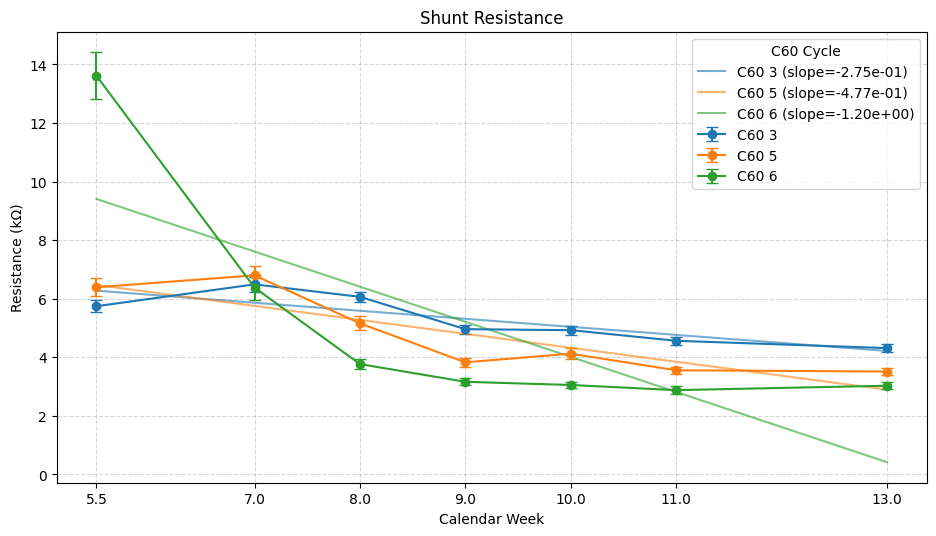

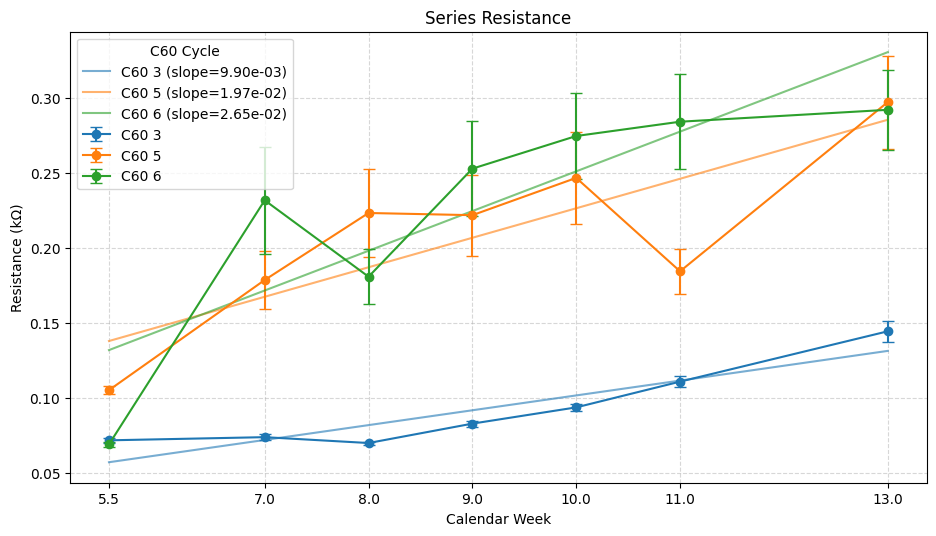

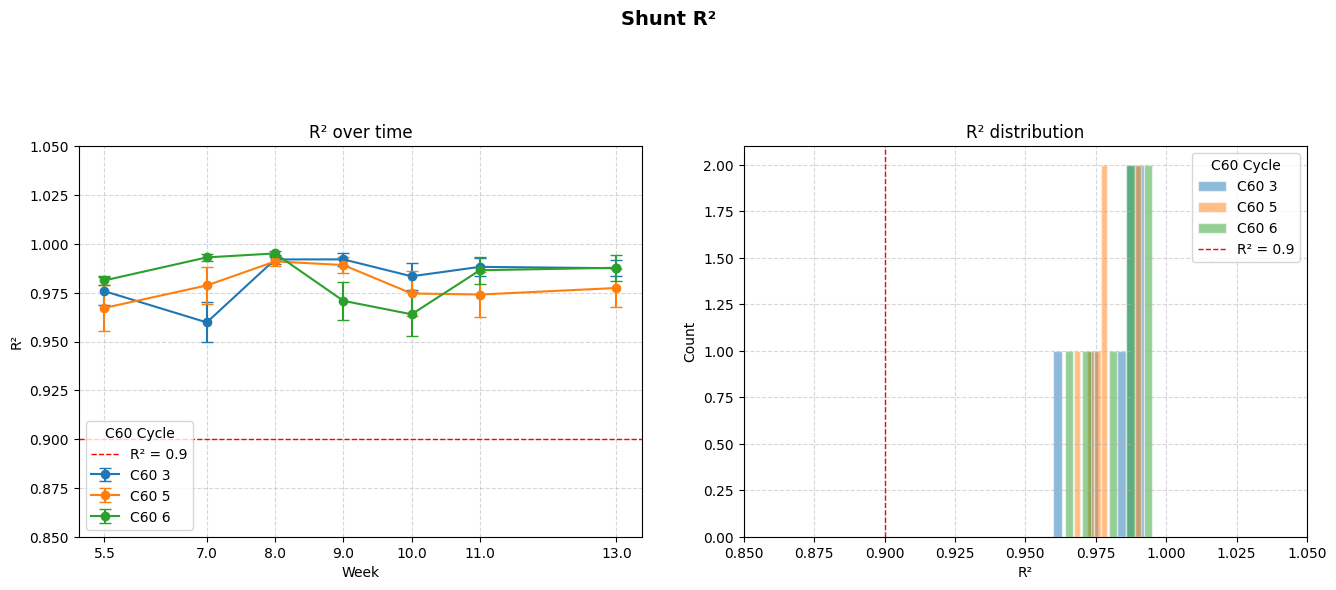

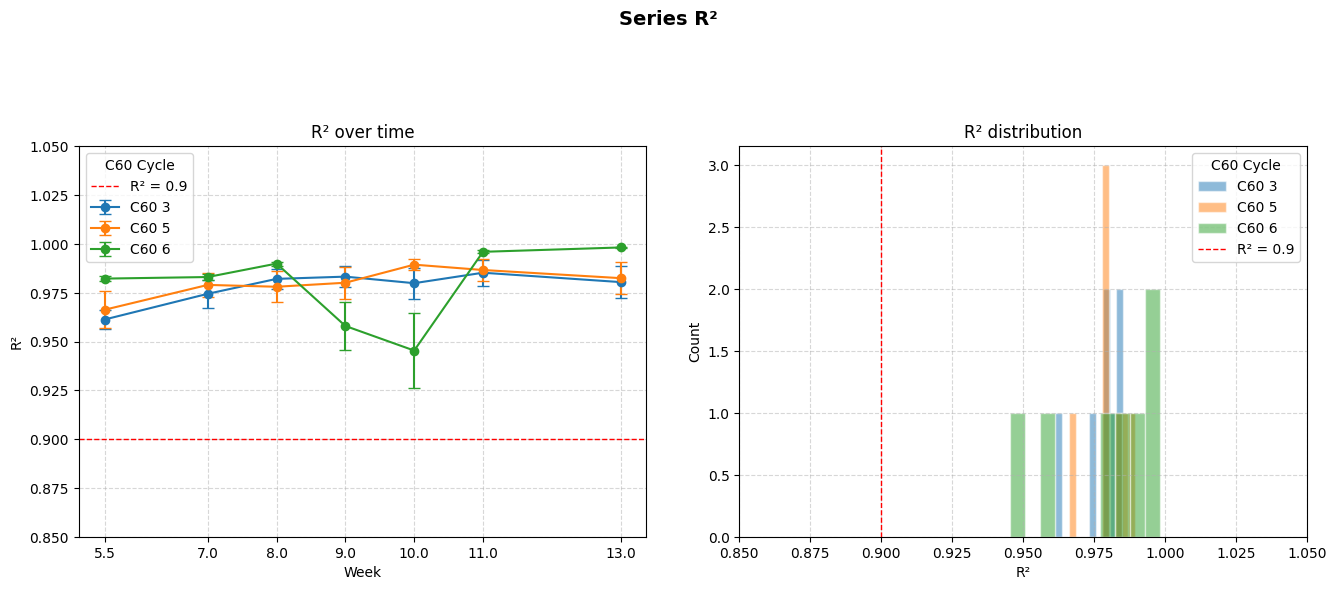

In [10]:
# ============================================================
# RESISTANCE ANALYSIS — MAIN CELL
# ============================================================

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
H5_FILE_PATH    = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Final_Project/Given Guides/data_sp26.h5"
NUM_PIXELS      = 8
SHUNT_ROWS      = list(range(5, 16))     # rows 5–15, 0-indexed
SHUNT_ROWS.remove(10)                    # exclude row 10 (V=0)
SERIES_ROWS     = list(range(64, 70))    # rows 64–69, 0-indexed
V_COL           = 0                      # Voltage (V)
J_COL           = 1                      # Forward_mean (mA)
R2_THRESHOLD    = 0.85                   # minimum R² to include resistance value
SIGMA_THRESHOLD = 3.5                    # sigma clipping threshold

# ------------------------------------------------------------
# CELL → C60 CYCLE MAPPING  (your existing code feeds these)
# ------------------------------------------------------------
cycle_map = {
    3: c60_3,
    5: c60_5,
    6: c60_6,
}

# ------------------------------------------------------------
# OUTPUT STRUCTURE
# results[cycle][week_index] = [shunt_avg, series_avg, shunt_std, series_std, shunt_count, series_count]
# r2_results[cycle][week_index] = [shunt_r2_avg, series_r2_avg, shunt_r2_std, series_r2_std, count]
# ff_results[cycle][week_index] = [ff_avg, pce_avg, ff_std, pce_std, count]
# ------------------------------------------------------------
results         = {3: {}, 5: {}, 6: {}}
r2_results      = {3: {}, 5: {}, 6: {}}
ff_results      = {3: {}, 5: {}, 6: {}}
regression_data = {
    3: {"Rsh": [], "Rs": [], "FF": []},
    5: {"Rsh": [], "Rs": [], "FF": []},
    6: {"Rsh": [], "Rs": [], "FF": []},
}

num_weeks = 7

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------
with h5py.File(H5_FILE_PATH, "r") as hf:

    for cycle, cell_dict in cycle_map.items():

        # week_accumulator[week_index] = [shunt_sum, series_sum, shunt_sum_sq, series_sum_sq, shunt_count, series_count]
        week_accumulator = {i: [0.0, 0.0, 0.0, 0.0, 0, 0] for i in range(num_weeks)}
        r2_accumulator   = {i: [0.0, 0.0, 0.0, 0.0, 0] for i in range(num_weeks)}
        ff_accumulator   = {i: [0.0, 0.0, 0.0, 0.0, 0] for i in range(num_weeks)}
        low_r2_shunt     = 0
        low_r2_series    = 0

        # Temporary per-week raw value storage for sigma clipping
        week_rsh_vals        = {i: [] for i in range(num_weeks)}
        week_rs_vals         = {i: [] for i in range(num_weeks)}
        week_ff_vals         = {i: [] for i in range(num_weeks)}
        week_regression_vals = {i: [] for i in range(num_weeks)}  # (rsh, rs, ff) tuples — all three from the same cell

        for cell_key in cell_dict.values():
            cell_id = f"Cell{cell_key}"

            if cell_id not in hf:
                warnings.warn(f"Cell {cell_id} not found in HDF5 — skipping.")
                continue

            for px in range(1, NUM_PIXELS + 1):
                pixel_id = f"Pixel{px}"

                if pixel_id not in hf[cell_id]:
                    continue

                iv_group = hf[cell_id][pixel_id]["IV"]
                sorted_weeks = sorted(iv_group.keys())

                if len(sorted_weeks) < 7:
                    continue

                if len(sorted_weeks) == 8:
                    sorted_weeks = sorted_weeks[1:]

                for week_idx, date_str in enumerate(sorted_weeks):

                    data = iv_group[date_str]["Data"][:]

                    V   = data[SHUNT_ROWS,  V_COL]
                    J   = data[SHUNT_ROWS,  J_COL]
                    V_s = data[SERIES_ROWS, V_COL]
                    J_s = data[SERIES_ROWS, J_COL]

                    shunt_resistance  = compute_shunt(V, J)
                    series_resistance = compute_series(V_s, J_s)

                    shunt_r2, series_r2 = compute_r2(V, J, V_s, J_s)

                    if shunt_r2 < R2_THRESHOLD:
                        low_r2_shunt  += 1
                    if series_r2 < R2_THRESHOLD:
                        low_r2_series += 1

                    # Always accumulate R²
                    r2_accumulator[week_idx][0] += shunt_r2
                    r2_accumulator[week_idx][1] += series_r2
                    r2_accumulator[week_idx][2] += shunt_r2  ** 2
                    r2_accumulator[week_idx][3] += series_r2 ** 2
                    r2_accumulator[week_idx][4] += 1

                    # Store raw values for sigma clipping
                    if shunt_r2 >= R2_THRESHOLD:
                        week_rsh_vals[week_idx].append(shunt_resistance)

                    if series_r2 >= R2_THRESHOLD:
                        week_rs_vals[week_idx].append(series_resistance)

                    # Compute fill factor and PCE
                    ff, pce = compute_cell_metrics(data)
                    if not np.isnan(ff) and not np.isnan(pce):
                        week_ff_vals[week_idx].append((ff, pce))

                    # Combined gate — regression requires all three from the same cell
                    if (shunt_r2 >= R2_THRESHOLD and
                            series_r2 >= R2_THRESHOLD and
                            not np.isnan(ff)):
                        week_regression_vals[week_idx].append(
                            (shunt_resistance, series_resistance, ff)
                        )

        # ----------------------------------------------------
        # POST LOOP — sigma clip then accumulate separately
        # ----------------------------------------------------
        for week_idx in range(num_weeks):

            # Clip and accumulate shunt resistance
            if week_rsh_vals[week_idx]:
                rsh_arr, _ = iterative_sigma_clip(
                    week_rsh_vals[week_idx], SIGMA_THRESHOLD
                )
                for val in rsh_arr:
                    week_accumulator[week_idx][0] += val
                    week_accumulator[week_idx][2] += val ** 2
                    week_accumulator[week_idx][4] += 1  # shunt count

            # Clip and accumulate series resistance
            if week_rs_vals[week_idx]:
                rs_arr, _ = iterative_sigma_clip(
                    week_rs_vals[week_idx], SIGMA_THRESHOLD
                )
                for val in rs_arr:
                    week_accumulator[week_idx][1] += val
                    week_accumulator[week_idx][3] += val ** 2
                    week_accumulator[week_idx][5] += 1  # series count

            # Clip and accumulate fill factor
            if week_ff_vals[week_idx]:
                ff_raw  = [x[0] for x in week_ff_vals[week_idx]]
                pce_raw = [x[1] for x in week_ff_vals[week_idx]]
                ff_arr, _  = iterative_sigma_clip(ff_raw,  SIGMA_THRESHOLD)
                ff_mean    = np.mean(ff_arr)
                ff_sigma   = np.std(ff_arr)
                mask       = np.abs(np.array(ff_raw) - ff_mean) <= SIGMA_THRESHOLD * ff_sigma

                for ff_val, pce_val in zip(
                    np.array(ff_raw)[mask],
                    np.array(pce_raw)[mask]
                ):
                    ff_accumulator[week_idx][0] += ff_val
                    ff_accumulator[week_idx][1] += pce_val
                    ff_accumulator[week_idx][2] += ff_val  ** 2
                    ff_accumulator[week_idx][3] += pce_val ** 2
                    ff_accumulator[week_idx][4] += 1

        # ----------------------------------------------------
        # Build regression_data from clipped values
        # All three measurements guaranteed from the same cell
        # ----------------------------------------------------
        for week_idx in range(num_weeks):
            if not week_regression_vals[week_idx]:
                continue

            rsh_raw = [x[0] for x in week_regression_vals[week_idx]]
            rs_raw  = [x[1] for x in week_regression_vals[week_idx]]
            ff_raw  = [x[2] for x in week_regression_vals[week_idx]]

            rsh_mean  = np.mean(rsh_raw);  rsh_sigma = np.std(rsh_raw)
            rs_mean   = np.mean(rs_raw);   rs_sigma  = np.std(rs_raw)
            ff_mean   = np.mean(ff_raw);   ff_sigma  = np.std(ff_raw)

            for rsh_val, rs_val, ff_val in zip(rsh_raw, rs_raw, ff_raw):
                rsh_ok = abs(rsh_val - rsh_mean) <= SIGMA_THRESHOLD * rsh_sigma
                rs_ok  = abs(rs_val  - rs_mean)  <= SIGMA_THRESHOLD * rs_sigma
                ff_ok  = abs(ff_val  - ff_mean)  <= SIGMA_THRESHOLD * ff_sigma

                if rsh_ok and rs_ok and ff_ok:
                    regression_data[cycle]["Rsh"].append(rsh_val)
                    regression_data[cycle]["Rs"].append(rs_val)
                    regression_data[cycle]["FF"].append(ff_val)

        # Store averaged resistance results
        for week_idx, (shunt_sum, series_sum, shunt_sum_sq, series_sum_sq, shunt_count, series_count) in week_accumulator.items():
            if shunt_count == 0 and series_count == 0:
                warnings.warn(
                    f"Cycle {cycle}, week {week_idx}: no data collected — skipping."
                )
                continue
            results[cycle][week_idx] = [
                shunt_sum  / shunt_count  if shunt_count  > 0 else np.nan,
                series_sum / series_count if series_count > 0 else np.nan,
                np.sqrt((shunt_sum_sq  / shunt_count)  - (shunt_sum  / shunt_count)  ** 2) if shunt_count  > 0 else np.nan,
                np.sqrt((series_sum_sq / series_count) - (series_sum / series_count) ** 2) if series_count > 0 else np.nan,
                shunt_count,
                series_count,
            ]

        # Store averaged R² results
        for week_idx, (shunt_r2_sum, series_r2_sum, shunt_r2_sum_sq, series_r2_sum_sq, count) in r2_accumulator.items():
            if count == 0:
                continue
            r2_results[cycle][week_idx] = [
                shunt_r2_sum  / count,
                series_r2_sum / count,
                np.sqrt((shunt_r2_sum_sq  / count) - (shunt_r2_sum  / count) ** 2),
                np.sqrt((series_r2_sum_sq / count) - (series_r2_sum / count) ** 2),
                count,
            ]

        # Store averaged FF and PCE results
        for week_idx, (ff_sum, pce_sum, ff_sum_sq, pce_sum_sq, count) in ff_accumulator.items():
            if count == 0:
                warnings.warn(
                    f"Cycle {cycle}, week {week_idx}: no FF data collected — skipping."
                )
                continue
            ff_results[cycle][week_idx] = [
                ff_sum  / count,
                pce_sum / count,
                np.sqrt((ff_sum_sq  / count) - (ff_sum  / count) ** 2),
                np.sqrt((pce_sum_sq / count) - (pce_sum / count) ** 2),
                count,
            ]

        # Summary warning for low R² fits
        total_fits = sum(r2_accumulator[i][4] for i in range(num_weeks))
        total_low  = low_r2_shunt + low_r2_series
        total_all  = total_fits * 2
        percentage = (total_low / total_all) * 100
        warnings.warn(
            f"\n"
            f"================================================\n"
            f"Cycle {cycle}: {total_low} of {total_all} fits\n"
            f"below R² threshold of {R2_THRESHOLD} ({percentage:.1f}%)\n"
            f"(shunt: {low_r2_shunt}, series: {low_r2_series})\n"
            f"================================================"
        )

# ------------------------------------------------------------
# GRAPHING
# ------------------------------------------------------------
plot_resistance(results, num_weeks, resistance_type="shunt")
plot_resistance(results, num_weeks, resistance_type="series")
plot_r2(r2_results, num_weeks, r2_type="shunt")
plot_r2(r2_results, num_weeks, r2_type="series")

Below is a plotting function to graph the relationship between fill factor and time in weeks.

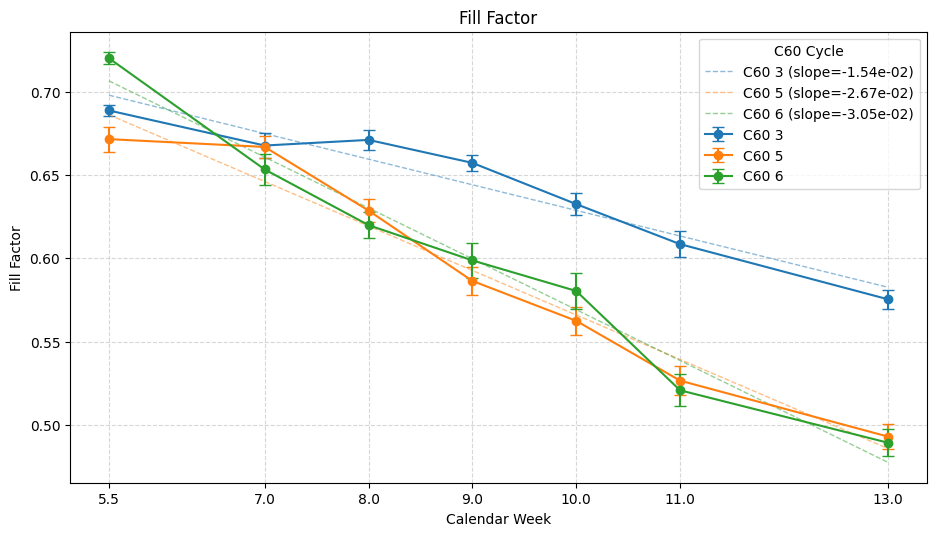

In [11]:
# ============================================================
# FUNCTION — plot_fill_factor
# ============================================================

def plot_fill_factor(ff_results, num_weeks):
    """
    Plots average fill factor over time for each C60 cycle.
    One data point per week, one line per cycle, with error bars.

    Parameters:
        ff_results : dict structured as ff_results[cycle][week_idx]
                     = [ff_avg, pce_avg, ff_std, pce_std, count]
        num_weeks  : total number of weeks (int)
    """

    week_numbers = [5.5, 7, 8, 9, 10, 11, 13]

    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60 3"},
        5: {"color": "tab:orange", "label": "C60 5"},
        6: {"color": "tab:green",  "label": "C60 6"},
    }

    fig, ax = plt.subplots(figsize=(10, 6))

    for cycle, style in cycle_styles.items():
        avgs = []
        sems = []

        for week_idx in range(num_weeks):
            if week_idx not in ff_results[cycle]:
                avgs.append(np.nan)
                sems.append(np.nan)
            else:
                std   = ff_results[cycle][week_idx][2]
                count = ff_results[cycle][week_idx][4]
                avgs.append(ff_results[cycle][week_idx][0])
                sems.append(std / np.sqrt(count))

        # Trend line
        valid = [(w, a) for w, a in zip(week_numbers, avgs) if not np.isnan(a)]
        if len(valid) > 1:
            wx, wy  = zip(*valid)
            slope, intercept = np.polyfit(wx, wy, 1)
            trend_y = [slope * w + intercept for w in week_numbers]
            ax.plot(
                week_numbers, trend_y,
                color=style["color"],
                linewidth=1,
                linestyle="--",
                alpha=0.5,
                label=f"C60 {cycle} (slope={slope:.2e})",
            )

        ax.errorbar(
            week_numbers,
            avgs,
            yerr=sems,
            label=style["label"],
            color=style["color"],
            marker="o",
            capsize=4,
            linewidth=1.5,
        )

    ax.set_title("Fill Factor")
    ax.set_xlabel("Calendar Week")
    ax.set_ylabel("Fill Factor")
    ax.set_xticks(week_numbers)
    ax.legend(title="C60 Cycle")
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()


plot_fill_factor(ff_results, num_weeks)

The multivariable linear regression cell takes individual pixel level observations for shunt resistance, series resistance, and fill factor and fits a linear model of the form FF = β₀ + β₁(Rsh) + β₂(Rs) independently for each C60 cycle. Only observations where both resistance fits passed the R² quality threshold are included, ensuring the regression is built on reliable data points. The output table reports the coefficient, standard error, and p-value for each parameter. The coefficient tells you the direction and magnitude of each resistance type's influence on fill factor — a positive β₁ means higher shunt resistance improves fill factor while a negative β₂ means higher series resistance reduces it. The p-value indicates statistical significance — values below 0.05 are marked with asterisks and values marked *** indicate the relationship is significant at the p < 0.001 level, meaning there is less than a 0.1% chance the relationship occurred by chance. The R² at the top of each cycle reports how much of the fill factor variance is explained by resistance alone.

In [12]:
# ============================================================
# MULTIVARIABLE LINEAR REGRESSION CELL
# ============================================================

from scipy import stats
import numpy as np

# Store regression results for each cycle
# reg_results[cycle] = {
#     "coeffs"     : [β₀, β₁(Rsh), β₂(Rs)],
#     "r2"         : R² of the model,
#     "p_values"   : [p_β₀, p_β₁, p_β₂],
#     "predictions": array of predicted FF values,
#     "actuals"    : array of actual FF values,
# }
reg_results = {}

for cycle in [3, 5, 6]:

    # Build arrays
    Rsh = np.array(regression_data[cycle]["Rsh"])
    Rs  = np.array(regression_data[cycle]["Rs"])
    FF  = np.array(regression_data[cycle]["FF"])

    n   = len(FF)

    # Build design matrix [1, Rsh, Rs]
    X   = np.column_stack([np.ones(n), Rsh, Rs])

    # Fit via least squares
    coeffs, residuals, rank, sv = np.linalg.lstsq(X, FF, rcond=None)

    # Predictions and R²
    FF_pred = X @ coeffs
    ss_res  = np.sum((FF - FF_pred) ** 2)
    ss_tot  = np.sum((FF - np.mean(FF)) ** 2)
    r2      = 1 - (ss_res / ss_tot)

    # Standard errors and p-values

    dof        = n - X.shape[1]                     # degrees of freedom (n minus number of parameters)
    residuals  = FF - FF_pred                       # per observation prediction error
    X_inv      = np.linalg.inv(X.T @ X)            # inverse of XᵀX scaling matrix
    meat       = (X * residuals[:, np.newaxis]).T @ (X * residuals[:, np.newaxis])      # XᵀX reweighted by each observation's squared residual
    cov_robust = X_inv @ meat @ X_inv              # sandwich covariance matrix — HC robust estimate
    se         = np.sqrt(np.diag(cov_robust))       # robust standard errors
    t_stats    = coeffs / se                        # t-statistics
    p_vals     = [2 * (1 - stats.t.cdf(abs(t), dof)) for t in t_stats]  # two-tailed p-values

    reg_results[cycle] = {
        "coeffs"     : coeffs,
        "r2"         : r2,
        "p_values"   : p_vals,
        "se"         : se,
        "predictions": FF_pred,
        "actuals"    : FF,
    }

    # Normalized coefficients as percentage of mean FF
    mean_FF     = FF.mean()
    pct_beta1   = (coeffs[1] / mean_FF) * 100
    pct_beta2   = (coeffs[2] / mean_FF) * 100

    # Print summary
    print(f"\n{'='*55}")
    print(f"  Cycle {cycle} — Multivariable Linear Regression")
    print(f"{'='*55}")
    print(f"  n = {n} observations")
    print(f"  Model: FF = β₀ + β₁(Rsh) + β₂(Rs)")
    print(f"  R²    = {r2:.4f}")
    print(f"\n  {'Parameter':<12} {'Coefficient':>14} {'Std Error':>12} {'p-value':>12}")
    print(f"  {'-'*52}")
    labels = ["β₀ (intercept)", "β₁ (Rsh)", "β₂ (Rs)"]
    for label, coeff, se_val, p in zip(labels, coeffs, se, p_vals):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {label:<16} {coeff:>12.6f} {se_val:>12.6f} {p:>12.6f} {sig}")
    print(f"\n  Significance: *** p<0.001  ** p<0.01  * p<0.05")



    Rsh_range    = Rsh.max() - Rsh.min()
    Rs_range     = Rs.max()  - Rs.min()
    effect_Rsh   = (coeffs[1] * Rsh_range / mean_FF) * 100
    effect_Rs    = (coeffs[2] * Rs_range  / mean_FF) * 100

    print(f"\n  Range-based effects (relative to mean FF = {mean_FF:.3f}):")
    print(f"  Rsh range: {Rsh_range:.3f} kΩ  →  {effect_Rsh:+.1f}% FF change")
    print(f"  Rs range:  {Rs_range:.3f} kΩ  →  {effect_Rs:+.1f}% FF change")


  Cycle 3 — Multivariable Linear Regression
  n = 937 observations
  Model: FF = β₀ + β₁(Rsh) + β₂(Rs)
  R²    = 0.3889

  Parameter       Coefficient    Std Error      p-value
  ----------------------------------------------------
  β₀ (intercept)       0.650136     0.010601     0.000000 ***
  β₁ (Rsh)             0.012691     0.001378     0.000000 ***
  β₂ (Rs)             -0.829572     0.051936     0.000000 ***

  Significance: *** p<0.001  ** p<0.01  * p<0.05

  Range-based effects (relative to mean FF = 0.641):
  Rsh range: 15.889 kΩ  →  +31.4% FF change
  Rs range:  0.350 kΩ  →  -45.3% FF change

  Cycle 5 — Multivariable Linear Regression
  n = 677 observations
  Model: FF = β₀ + β₁(Rsh) + β₂(Rs)
  R²    = 0.3591

  Parameter       Coefficient    Std Error      p-value
  ----------------------------------------------------
  β₀ (intercept)       0.544332     0.008160     0.000000 ***
  β₁ (Rsh)             0.017149     0.001662     0.000000 ***
  β₂ (Rs)             -0.162223  

The graphing function below produces two figures. The first contains three scatter plots — one per C60 cycle — comparing actual measured fill factor against the fill factor predicted by the regression model for each individual pixel observation. Points clustering along the diagonal indicate a strong model fit. The R² value shown for each cycle represents how much of the variance in fill factor is explained by shunt and series resistance together. The second figure contains two bar charts depicting the regression coefficients for each resistance type across all three cycles. The positive β₁ values confirm that higher shunt resistance improves fill factor, while the negative β₂ values confirm that higher series resistance reduces fill factor. The magnitude of each bar indicates how sensitive fill factor is to changes in that resistance type for a given cycle.

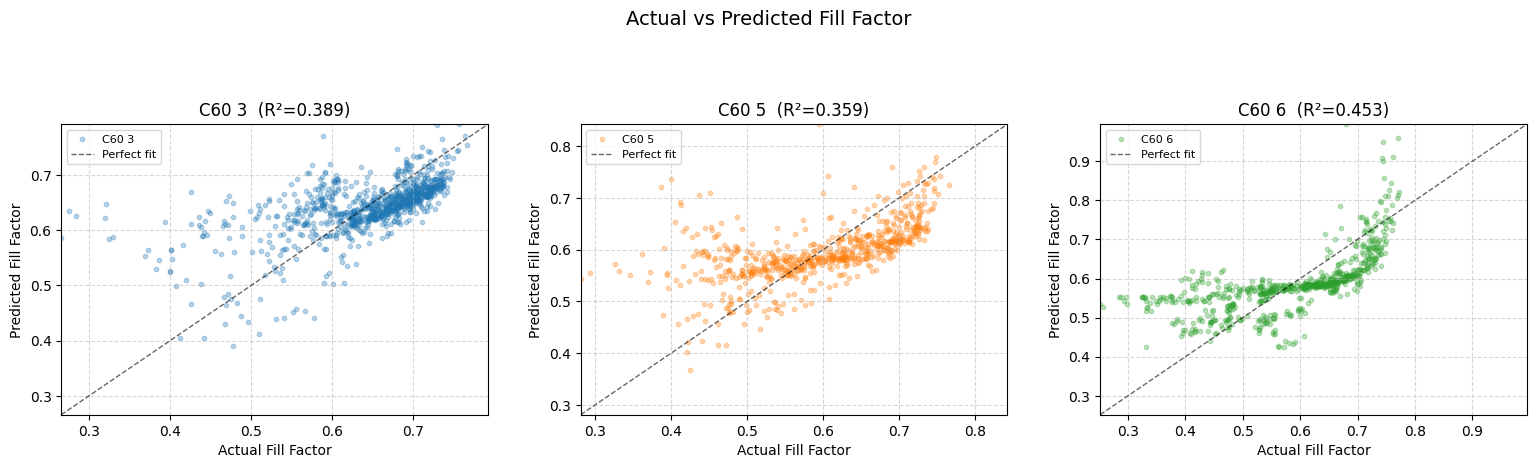

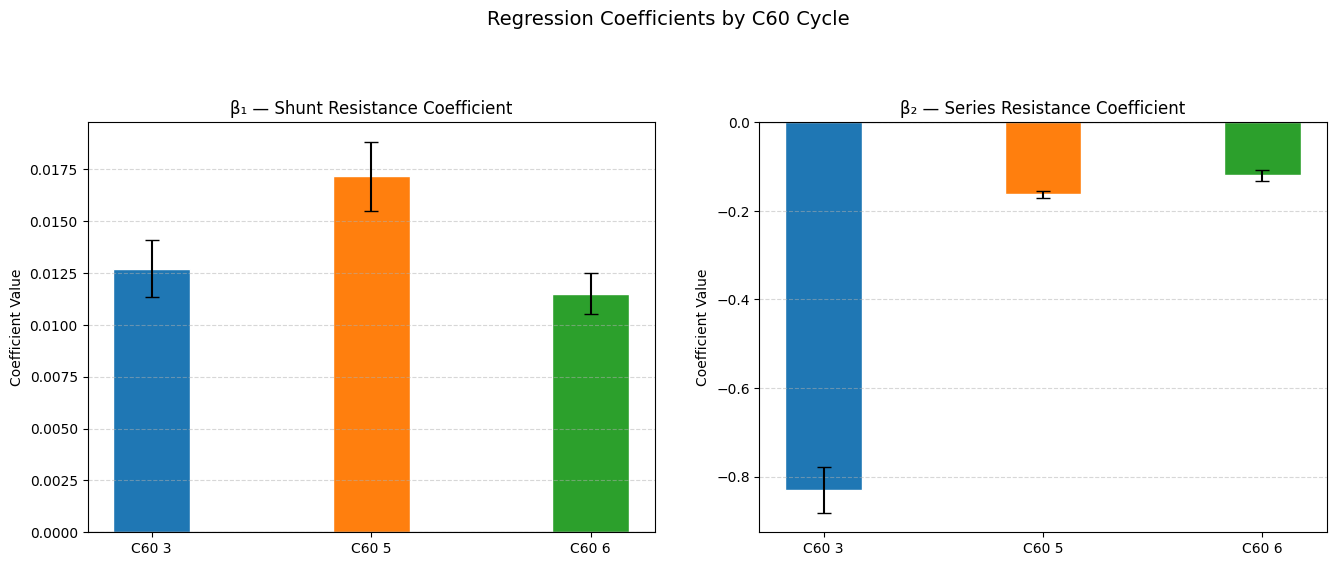

In [13]:
# @title
# ============================================================
# FUNCTION — plot_actual_vs_predicted
# ============================================================

def plot_actual_vs_predicted(reg_results):
    """
    Plots actual vs predicted fill factor for each C60 cycle.
    Points clustering along the diagonal indicate a good model fit.

    Parameters:
        reg_results : dict — output from regression cell
    """

    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60 3"},
        5: {"color": "tab:orange", "label": "C60 5"},
        6: {"color": "tab:green",  "label": "C60 6"},
    }

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Actual vs Predicted Fill Factor", fontsize=14)

    for ax, (cycle, style) in zip(axes, cycle_styles.items()):
        actuals     = reg_results[cycle]["actuals"]
        predictions = reg_results[cycle]["predictions"]
        r2          = reg_results[cycle]["r2"]

        ax.scatter(
            actuals, predictions,
            color=style["color"],
            alpha=0.3,
            s=10,
            label=style["label"],
        )

        # Perfect fit reference line
        lims = [
            min(actuals.min(), predictions.min()),
            max(actuals.max(), predictions.max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=1, alpha=0.6, label="Perfect fit")

        ax.set_title(f"{style['label']}  (R²={r2:.3f})")
        ax.set_xlabel("Actual Fill Factor")
        ax.set_ylabel("Predicted Fill Factor")
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(pad=3.0)
    plt.show()


# ============================================================
# FUNCTION — plot_coefficients
# ============================================================

def plot_coefficients(reg_results):
    """
    Plots β₁ (Rsh) and β₂ (Rs) coefficients side by side for
    all three C60 cycles with standard error bars.
    Larger magnitude = stronger influence on fill factor.

    Parameters:
        reg_results : dict — output from regression cell
    """

    cycles       = [3, 5, 6]
    cycle_labels = ["C60 3", "C60 5", "C60 6"]
    colors       = ["tab:blue", "tab:orange", "tab:green"]

    beta1 = [reg_results[c]["coeffs"][1]  for c in cycles]
    beta2 = [reg_results[c]["coeffs"][2]  for c in cycles]
    se1   = [reg_results[c]["se"][1]      for c in cycles]
    se2   = [reg_results[c]["se"][2]      for c in cycles]

    x     = np.arange(len(cycles))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Regression Coefficients by C60 Cycle", fontsize=14)

    # β₁ (Rsh)
    axes[0].bar(
        x, beta1,
        width=width,
        color=colors,
        yerr=se1,
        capsize=5,
        edgecolor="white",
    )
    axes[0].axhline(y=0, color="black", linewidth=0.8)
    axes[0].set_title("β₁ — Shunt Resistance Coefficient")
    axes[0].set_ylabel("Coefficient Value")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cycle_labels)
    axes[0].grid(True, linestyle="--", alpha=0.5, axis="y")

    # β₂ (Rs)
    axes[1].bar(
        x, beta2,
        width=width,
        color=colors,
        yerr=se2,
        capsize=5,
        edgecolor="white",
    )
    axes[1].axhline(y=0, color="black", linewidth=0.8)
    axes[1].set_title("β₂ — Series Resistance Coefficient")
    axes[1].set_ylabel("Coefficient Value")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(cycle_labels)
    axes[1].grid(True, linestyle="--", alpha=0.5, axis="y")

    plt.tight_layout(pad=3.0)
    plt.show()

plot_actual_vs_predicted(reg_results)
plot_coefficients(reg_results)

The six graphs below represent the final data representation of this project. Each graph is a dual y-axis plot where the left axis shows resistance in kΩ and the right axis shows fill factor. The x-axis represents time in calendar weeks consistent with all previous graphs. Each cycle is represented by two graphs — one pairing shunt resistance with fill factor and one pairing series resistance with fill factor — allowing the relationship between each resistance type and cell efficiency to be observed independently. Dashed trend lines are included for both variables to aid visualization of the overall direction of change over time. The slope values shown in the legend quantify the rate of change per calendar week for each variable.

The large error bar observed at week 10 for C60-5 and C60-6 series resistance is not a data quality issue but rather reflects genuine cell-to-cell variability in series resistance degradation at that point in the experiment subset of cells in both cycles experienced more rapid series resistance increases at that week while others remained stable, producing a wider spread in the average. This variability itself is a meaningful finding about the consistency of C60-5 and C60-6 cell behavior under stress conditions.

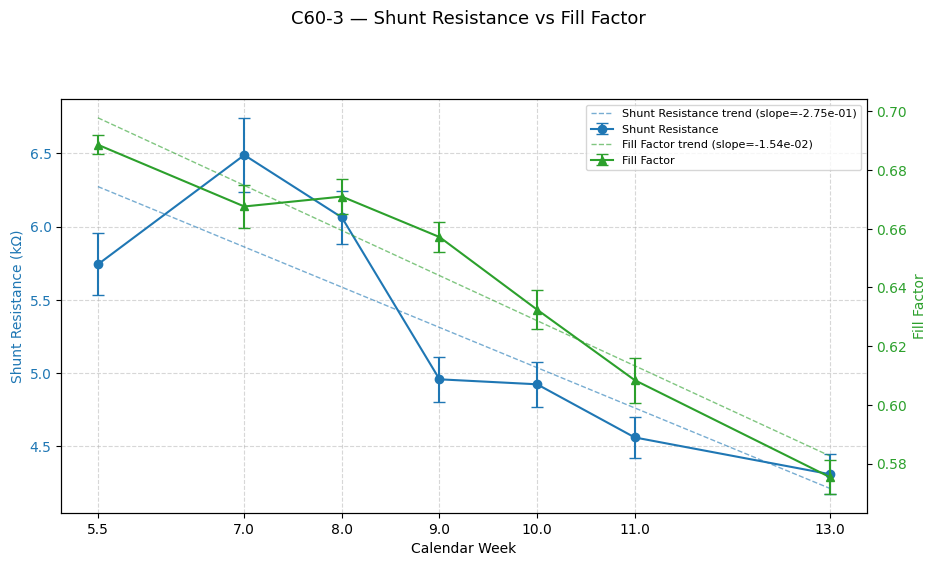

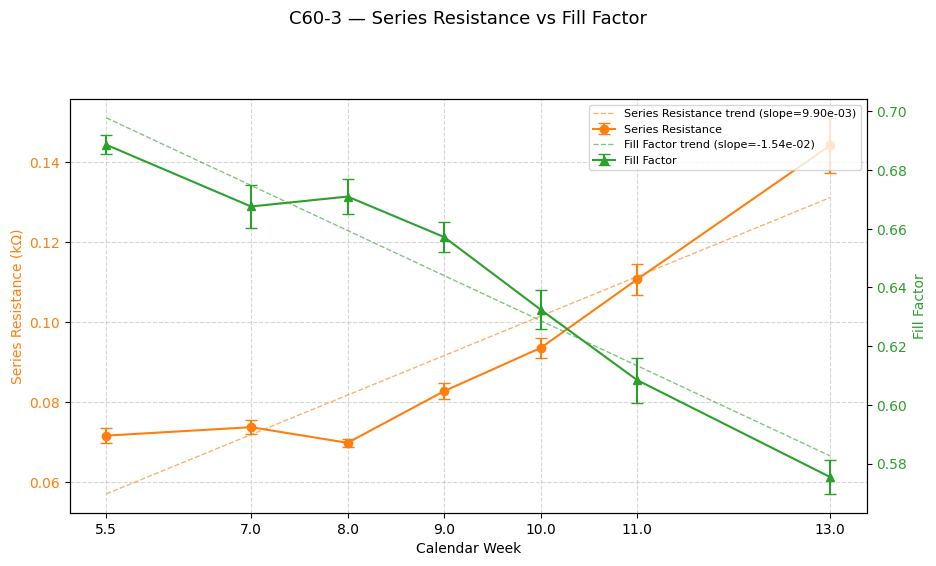

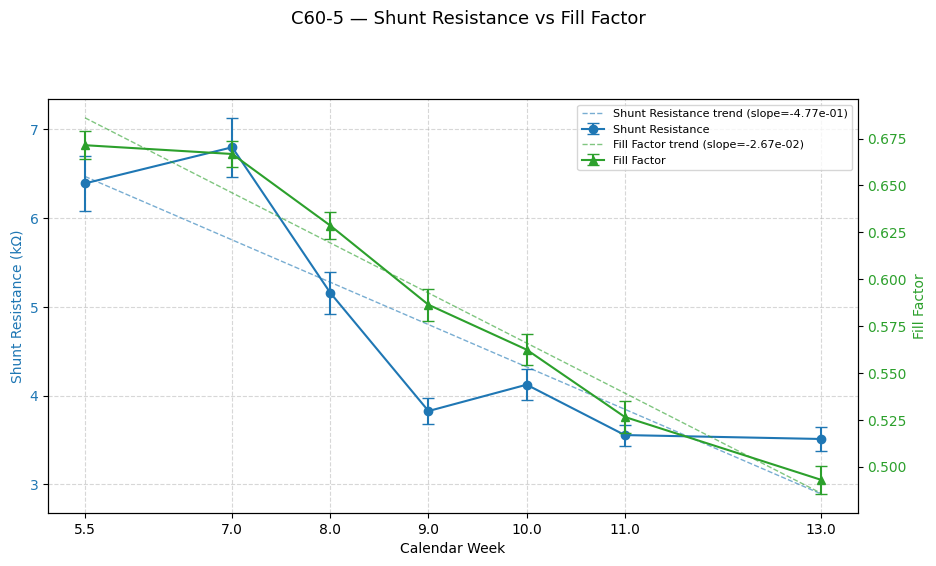

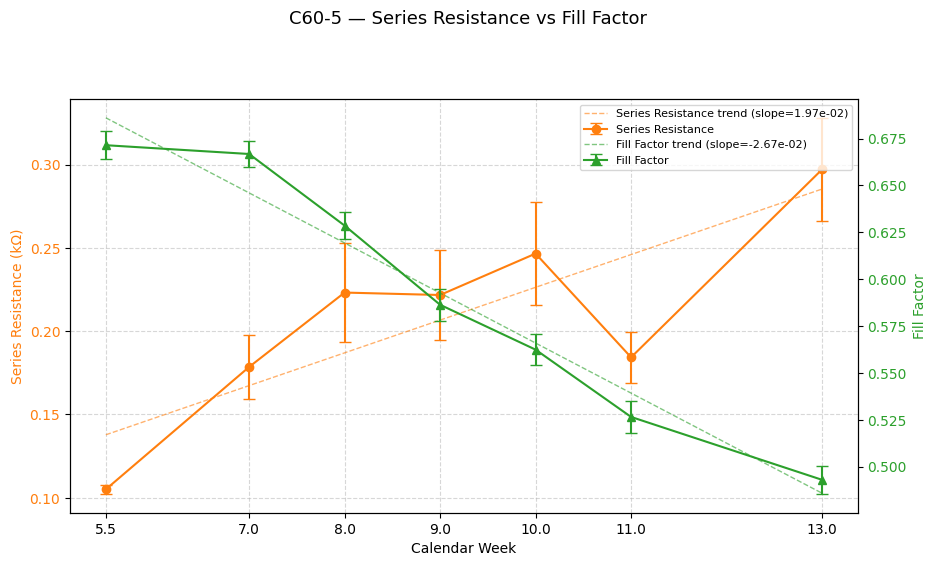

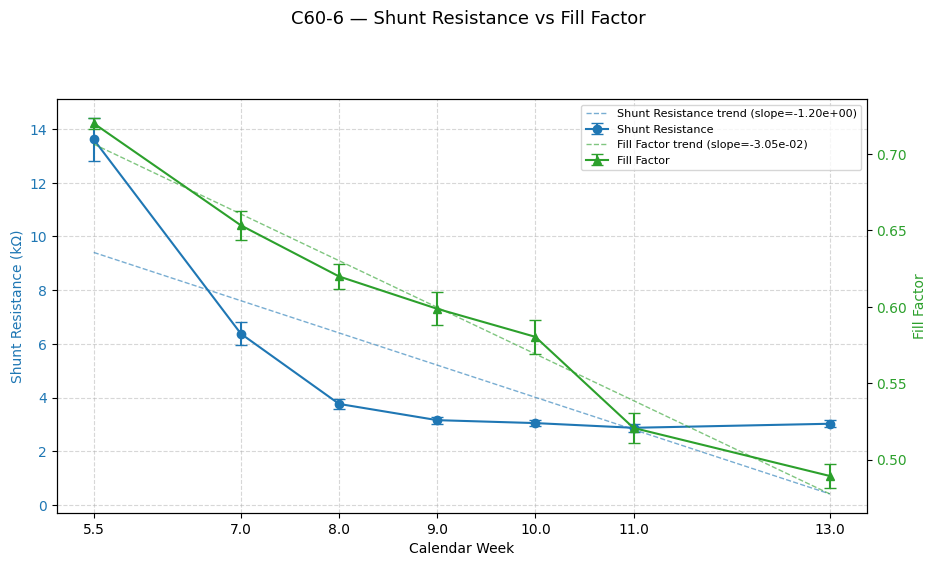

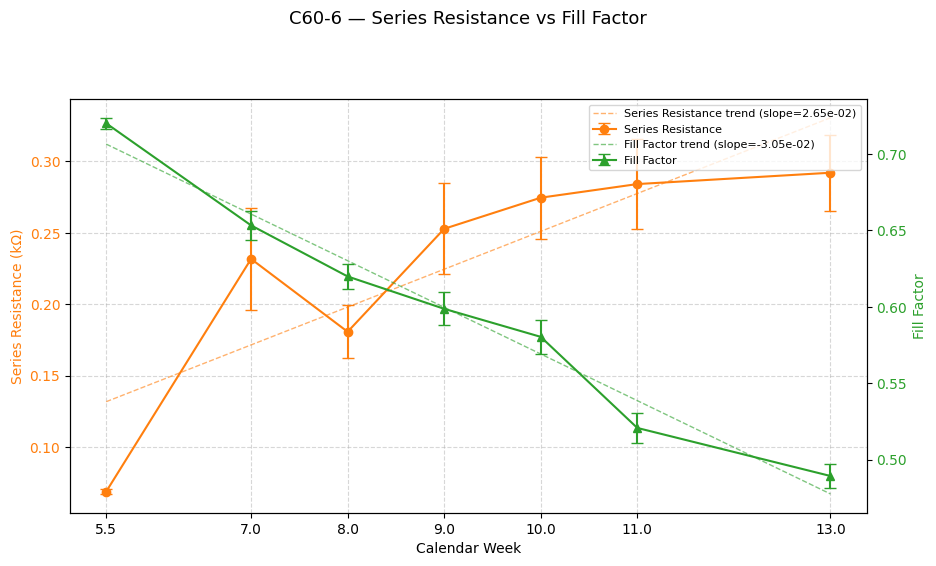

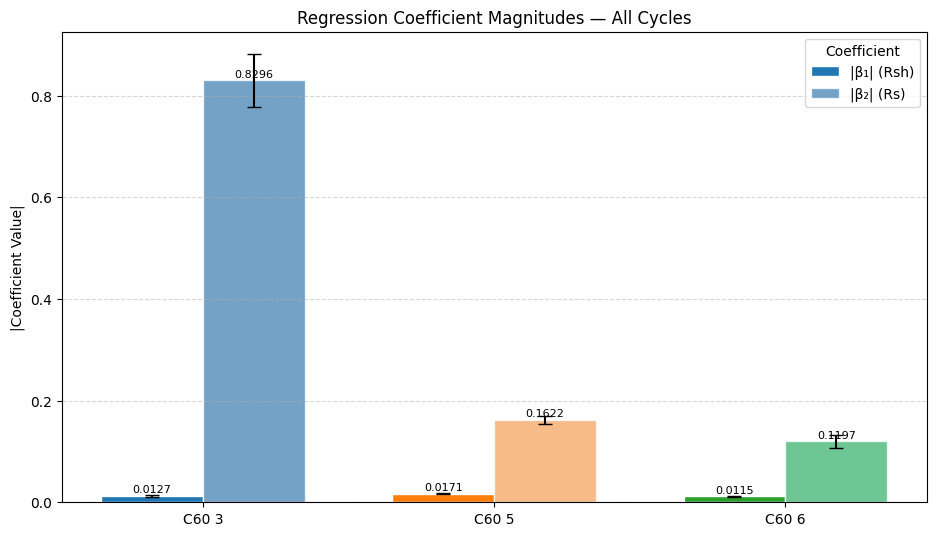

In [14]:
# ============================================================
# FUNCTION — plot_final_representation
# ============================================================

def plot_final_representation(results, ff_results, num_weeks):
    """
    Produces six dual y-axis graphs — one per cycle per resistance
    type — showing resistance and fill factor trends over time.
    Left y-axis shows resistance (kΩ), right y-axis shows fill
    factor. Trend lines are included for both variables.

    Parameters:
        results    : resistance results dict
        ff_results : fill factor results dict
        num_weeks  : total number of weeks (int)
    """

    week_numbers = [5.5, 7, 8, 9, 10, 11, 13]

    cycles = {
        3: "C60-3",
        5: "C60-5",
        6: "C60-6",
    }

    resistance_configs = [
        {
            "label"    : "Shunt Resistance",
            "avg_idx"  : 0,
            "std_idx"  : 2,
            "count_idx": 4,
            "color"    : "tab:blue",
            "ylabel"   : "Shunt Resistance (kΩ)",
        },
        {
            "label"    : "Series Resistance",
            "avg_idx"  : 1,
            "std_idx"  : 3,
            "count_idx": 5,
            "color"    : "tab:orange",
            "ylabel"   : "Series Resistance (kΩ)",
        },
    ]


    for cycle, cycle_label in cycles.items():

        # Build fill factor arrays once per cycle
        ff_avgs = []
        ff_sems = []
        for week_idx in range(num_weeks):
            if week_idx in ff_results[cycle]:
                std   = ff_results[cycle][week_idx][2]
                count = ff_results[cycle][week_idx][4]
                ff_avgs.append(ff_results[cycle][week_idx][0])
                ff_sems.append(std / np.sqrt(count))
            else:
                ff_avgs.append(np.nan)
                ff_sems.append(np.nan)

        # FF trend line
        valid_ff = [(w, a) for w, a in zip(week_numbers, ff_avgs)
                    if not np.isnan(a)]
        ff_slope, ff_intercept = np.polyfit(*zip(*valid_ff), 1)
        ff_trend = [ff_slope * w + ff_intercept for w in week_numbers]

        for res_config in resistance_configs:

            # Build resistance arrays
            res_avgs = []
            res_sems = []
            for week_idx in range(num_weeks):
                if week_idx in results[cycle]:
                    std = results[cycle][week_idx][res_config["std_idx"]]
                    count = results[cycle][week_idx][res_config["count_idx"]]
                    res_avgs.append(results[cycle][week_idx][res_config["avg_idx"]])
                    res_sems.append(std / np.sqrt(count))
                else:
                    res_avgs.append(np.nan)
                    res_sems.append(np.nan)

            # Resistance trend line
            valid_res = [(w, a) for w, a in zip(week_numbers, res_avgs)
                         if not np.isnan(a)]
            res_slope, res_intercept = np.polyfit(*zip(*valid_res), 1)
            res_trend = [res_slope * w + res_intercept for w in week_numbers]

            # Build figure
            fig, ax1 = plt.subplots(figsize=(10, 6))
            fig.suptitle(
                f"{cycle_label} — {res_config['label']} vs Fill Factor",
                fontsize=13
            )

            # Left axis — resistance
            ax1.errorbar(
                week_numbers, res_avgs, yerr=res_sems,
                color=res_config["color"],
                marker="o",
                capsize=4,
                linewidth=1.5,
                label=res_config["label"],
            )
            ax1.plot(
                week_numbers, res_trend,
                color=res_config["color"],
                linewidth=1,
                linestyle="--",
                alpha=0.6,
                label=f"{res_config['label']} trend (slope={res_slope:.2e})",
            )
            ax1.set_xlabel("Calendar Week")
            ax1.set_ylabel(res_config["ylabel"], color=res_config["color"])
            ax1.tick_params(axis="y", labelcolor=res_config["color"])
            ax1.set_xticks(week_numbers)
            ax1.grid(True, linestyle="--", alpha=0.5)

            # Right axis — fill factor
            ax2 = ax1.twinx()
            ax2.errorbar(
                week_numbers, ff_avgs, yerr=ff_sems,
                color="tab:green",
                marker="^",
                capsize=4,
                linewidth=1.5,
                label="Fill Factor",
            )
            ax2.plot(
                week_numbers, ff_trend,
                color="tab:green",
                linewidth=1,
                linestyle="--",
                alpha=0.6,
                label=f"Fill Factor trend (slope={ff_slope:.2e})",
            )
            ax2.set_ylabel("Fill Factor", color="tab:green")
            ax2.tick_params(axis="y", labelcolor="tab:green")

            # Combined legend
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(
                lines1 + lines2,
                labels1 + labels2,
                loc="upper right",
                fontsize=8,
            )

            plt.tight_layout(pad=3.0)
            plt.show()

plot_final_representation(results, ff_results, num_weeks)


#Adds a set of graphs for the beta values to compare magnitudes.
#The values are shown as absolute values so that everything is on the same axis
#Remember that series resistance is negative and shunt is positve beta values

cycles       = [3, 5, 6]
cycle_labels = ["C60 3", "C60 5", "C60 6"]
colors_b1    = ["tab:blue",   "tab:orange", "tab:green"]
colors_b2    = ["steelblue",  "sandybrown", "mediumseagreen"]

beta1 = [abs(reg_results[c]["coeffs"][1]) for c in cycles]
beta2 = [abs(reg_results[c]["coeffs"][2]) for c in cycles]
se1   = [reg_results[c]["se"][1]          for c in cycles]
se2   = [reg_results[c]["se"][2]          for c in cycles]

x     = np.arange(len(cycles))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, beta1, width, yerr=se1, capsize=5,
               color=colors_b1, edgecolor="white", label="|β₁| (Rsh)")
bars2 = ax.bar(x + width/2, beta2, width, yerr=se2, capsize=5,
               color=colors_b2, edgecolor="white", alpha=0.75, label="|β₂| (Rs)")

ax.set_title("Regression Coefficient Magnitudes — All Cycles")
ax.set_ylabel("|Coefficient Value|")
ax.set_xticks(x)
ax.set_xticklabels(cycle_labels)
ax.legend(title="Coefficient")
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f"{h:.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
            f"{h:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout(pad=3.0)
plt.show()

The rest of this file is debugging functions used to check that our current data and functions were providing the necessary output.
Any further debugging can be coded and documented here.

1.   The first function allows us to evaluate the weeks of data collection within each cell. The output shows which calandar dates are contained within each data collection period to determine if we have the dates properly aligned.
2.   The second function simply makes sure that the previous function correctly alligned all of the cells and checks the alignment post calculations.
3.   This function investigates the series resistance in both c60 5 and 6, more specifically at week 10. This is to address the spike in resistance that can be viewed on the graph.
4.   This Function will debug and test the idea of using sigma clipping to determine if this will be a good statistical fit, and if so, what sigma value best filters the data.
5.   Further debugging to test the sigma clipping and refine the process we are using.
6.   A large set of mathematical sets to review the sigma clipping results. This is being used to understand the results better and make sure everything being seen is both meaningful and mathimatically accurate.
7.   One final graphing function to display the data results in only 2 graphs. This should be useful for the poster specifically but may have meaningful visualizations outside of the poster as well.

In [15]:
# @title
# ============================================================
# DIAGNOSTIC — week alignment audit
# ============================================================

def audit_week_alignment(h5_path, cycle_map):
    """
    Audits date alignment across all cells and cycles.
    For each week index, shows which calendar dates are present
    and flags weeks where cells are not in the same calendar week.

    Parameters:
        h5_path   : str — path to HDF5 file
        cycle_map : dict — {cycle: cell_dict} mapping
    """

    from datetime import datetime, timedelta

    def get_calendar_week(date_str):
        """Returns (year, week_number) for a date string YYYY_MM_DD."""
        dt = datetime.strptime(date_str, "%Y_%m_%d")
        return dt.isocalendar()[:2]  # (year, week)

    with h5py.File(h5_path, "r") as hf:

        for cycle, cell_dict in cycle_map.items():
            print(f"\n{'='*60}")
            print(f"  C60 CYCLE {cycle}")
            print(f"{'='*60}")

            # Build a structure: week_idx -> {date_str -> [cell/pixel list]}
            week_date_map = {}

            for cell_key in cell_dict.values():
                cell_id = f"Cell{cell_key}"
                if cell_id not in hf:
                    continue

                for px in range(1, NUM_PIXELS + 1):
                    pixel_id = f"Pixel{px}"
                    if pixel_id not in hf[cell_id]:
                        continue

                    iv_group     = hf[cell_id][pixel_id]["IV"]
                    sorted_weeks = sorted(iv_group.keys())

                    if len(sorted_weeks) < 7:
                        continue

                    # Show original dates before any dropping
                    label = f"{cell_id}/{pixel_id}"

                    for week_idx, date_str in enumerate(sorted_weeks):
                        if week_idx not in week_date_map:
                            week_date_map[week_idx] = {}
                        if date_str not in week_date_map[week_idx]:
                            week_date_map[week_idx][date_str] = []
                        week_date_map[week_idx][date_str].append(label)

            # Report per week index
            for week_idx in sorted(week_date_map.keys()):
                dates_present = week_date_map[week_idx]
                unique_cal_weeks = set(
                    get_calendar_week(d) for d in dates_present.keys()
                )

                aligned = len(unique_cal_weeks) == 1
                status  = "OK" if aligned else "MISALIGNED"

                print(f"\n  Week index {week_idx} [{status}]")
                for date_str, cells in sorted(dates_present.items()):
                    cal_week = get_calendar_week(date_str)
                    print(f"    {date_str} (cal week {cal_week[1]:02d}) "
                          f"— {len(cells)} pixels")
                    # Uncomment below to see individual cell/pixel detail
                    # for c in cells:
                    #     print(f"      {c}")

                if not aligned:
                    print(f"    *** Calendar weeks present: "
                          f"{sorted(unique_cal_weeks)}")


audit_week_alignment(H5_FILE_PATH, cycle_map)


  C60 CYCLE 3

  Week index 0 [MISALIGNED]
    2026_01_27 (cal week 05) — 24 pixels
    2026_01_28 (cal week 05) — 48 pixels
    2026_01_29 (cal week 05) — 16 pixels
    2026_02_03 (cal week 06) — 16 pixels
    2026_02_05 (cal week 06) — 16 pixels
    2026_02_06 (cal week 06) — 24 pixels
    *** Calendar weeks present: [(2026, 5), (2026, 6)]

  Week index 1 [MISALIGNED]
    2026_02_04 (cal week 06) — 40 pixels
    2026_02_10 (cal week 07) — 40 pixels
    2026_02_12 (cal week 07) — 40 pixels
    2026_02_13 (cal week 07) — 24 pixels
    *** Calendar weeks present: [(2026, 6), (2026, 7)]

  Week index 2 [MISALIGNED]
    2026_02_11 (cal week 07) — 40 pixels
    2026_02_17 (cal week 08) — 40 pixels
    2026_02_19 (cal week 08) — 40 pixels
    2026_02_20 (cal week 08) — 24 pixels
    *** Calendar weeks present: [(2026, 7), (2026, 8)]

  Week index 3 [MISALIGNED]
    2026_02_18 (cal week 08) — 40 pixels
    2026_02_24 (cal week 09) — 40 pixels
    2026_02_26 (cal week 09) — 40 pixels
    202

In [16]:
# @title
# ============================================================
# DIAGNOSTIC — post-alignment week audit
# ============================================================

def audit_post_alignment(h5_path, cycle_map):
    """
    Audits week alignment AFTER the 8-week fix and week filtering
    have been applied, mirroring the exact logic of the main loop.
    Confirms that each week index contains only one calendar week
    across all contributing cells and pixels.

    Parameters:
        h5_path   : str — path to HDF5 file
        cycle_map : dict — {cycle: cell_dict} mapping
    """

    from datetime import datetime

    def get_calendar_week(date_str):
        dt = datetime.strptime(date_str, "%Y_%m_%d")
        return dt.isocalendar()[:2]  # (year, week_number)

    with h5py.File(h5_path, "r") as hf:

        for cycle, cell_dict in cycle_map.items():
            print(f"\n{'='*60}")
            print(f"  C60 CYCLE {cycle} — post alignment")
            print(f"{'='*60}")

            week_date_map = {}

            for cell_key in cell_dict.values():
                cell_id = f"Cell{cell_key}"
                if cell_id not in hf:
                    continue

                for px in range(1, NUM_PIXELS + 1):
                    pixel_id = f"Pixel{px}"
                    if pixel_id not in hf[cell_id]:
                        continue

                    iv_group     = hf[cell_id][pixel_id]["IV"]
                    sorted_weeks = sorted(iv_group.keys())

                    # Mirror main loop filtering exactly
                    if len(sorted_weeks) < 7:
                        continue

                    if len(sorted_weeks) == 8:
                        sorted_weeks = sorted_weeks[1:]  # drop index 0

                    for week_idx, date_str in enumerate(sorted_weeks):
                        if week_idx not in week_date_map:
                            week_date_map[week_idx] = {}
                        if date_str not in week_date_map[week_idx]:
                            week_date_map[week_idx][date_str] = 0
                        week_date_map[week_idx][date_str] += 1

            # Report
            all_aligned = True
            for week_idx in sorted(week_date_map.keys()):
                dates_present    = week_date_map[week_idx]
                unique_cal_weeks = set(
                    get_calendar_week(d) for d in dates_present.keys()
                )

                aligned = len(unique_cal_weeks) == 1
                status  = "OK" if aligned else "MISALIGNED"
                if not aligned:
                    all_aligned = False

                total_pixels = sum(dates_present.values())
                print(f"\n  Week index {week_idx} [{status}] — {total_pixels} pixels")

                for date_str, count in sorted(dates_present.items()):
                    cal_week = get_calendar_week(date_str)
                    print(f"    {date_str} (cal week {cal_week[1]:02d}) "
                          f"— {count} pixels")

                if not aligned:
                    print(f"    *** Calendar weeks present: "
                          f"{sorted(unique_cal_weeks)}")

            print(f"\n  {'ALL WEEKS ALIGNED' if all_aligned else 'WARNING — MISALIGNMENT DETECTED'}")

audit_post_alignment(H5_FILE_PATH, cycle_map)



  C60 CYCLE 3 — post alignment

  Week index 0 [MISALIGNED] — 144 pixels
    2026_01_27 (cal week 05) — 24 pixels
    2026_01_28 (cal week 05) — 8 pixels
    2026_01_29 (cal week 05) — 16 pixels
    2026_02_03 (cal week 06) — 16 pixels
    2026_02_04 (cal week 06) — 40 pixels
    2026_02_05 (cal week 06) — 16 pixels
    2026_02_06 (cal week 06) — 24 pixels
    *** Calendar weeks present: [(2026, 5), (2026, 6)]

  Week index 1 [OK] — 144 pixels
    2026_02_10 (cal week 07) — 40 pixels
    2026_02_11 (cal week 07) — 40 pixels
    2026_02_12 (cal week 07) — 40 pixels
    2026_02_13 (cal week 07) — 24 pixels

  Week index 2 [OK] — 144 pixels
    2026_02_17 (cal week 08) — 40 pixels
    2026_02_18 (cal week 08) — 40 pixels
    2026_02_19 (cal week 08) — 40 pixels
    2026_02_20 (cal week 08) — 24 pixels

  Week index 3 [OK] — 144 pixels
    2026_02_24 (cal week 09) — 40 pixels
    2026_02_25 (cal week 09) — 40 pixels
    2026_02_26 (cal week 09) — 40 pixels
    2026_02_27 (cal week 09) — 2

In [17]:
# @title
def inspect_week_10(cycle_dict, week_idx=5):
    """
    Prints Rs and R² for Pixel1 of every cell in a cycle at a given week index.
    """
    with h5py.File(H5_FILE_PATH, "r") as hf:
        for cell_key in cycle_dict.values():
            cell_id = f"Cell{cell_key}"
            if cell_id not in hf:
                continue
            pixel_id = "Pixel1"
            if pixel_id not in hf[cell_id]:
                continue
            iv_group = hf[cell_id][pixel_id]["IV"]
            sorted_weeks = sorted(iv_group.keys())
            if len(sorted_weeks) < 7:
                continue
            if len(sorted_weeks) == 8:
                sorted_weeks = sorted_weeks[1:]
            date_str = sorted_weeks[week_idx]
            data = iv_group[date_str]["Data"][:]
            V_s = data[SERIES_ROWS, V_COL]
            J_s = data[SERIES_ROWS, J_COL]
            coeffs = np.polyfit(J_s, V_s, 1)
            Rs = coeffs[0]
            y_pred = np.polyval(coeffs, J_s)
            ss_res = np.sum((V_s - y_pred) ** 2)
            ss_tot = np.sum((V_s - np.mean(V_s)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            print(f"{cell_id} week {week_idx+1} ({date_str}): Rs={Rs:.4f}  R²={r2:.4f}")

print("=== C60 5 — Week 6 (index 5) ===")
inspect_week_10(c60_5, week_idx=5)
print("\n=== C60 6 — Week 6 (index 5) ===")
inspect_week_10(c60_6, week_idx=5)

=== C60 5 — Week 6 (index 5) ===
CellR05 week 6 (2026_03_10): Rs=0.1083  R²=0.9919
CellR00 week 6 (2026_03_10): Rs=0.1540  R²=0.9889
CellA07 week 6 (2026_03_10): Rs=1.5082  R²=0.9998
CellA03 week 6 (2026_03_10): Rs=0.1759  R²=0.9734
CellR06 week 6 (2026_03_10): Rs=0.1210  R²=0.9976
CellA12 week 6 (2026_03_10): Rs=0.2160  R²=1.0000
CellR07 week 6 (2026_03_12): Rs=0.2105  R²=0.9986
CellR02 week 6 (2026_03_12): Rs=0.1299  R²=0.9929
CellR08 week 6 (2026_03_12): Rs=0.0963  R²=0.9988
CellR03 week 6 (2026_03_12): Rs=0.1177  R²=0.9946
CellA09 week 6 (2026_03_10): Rs=0.6236  R²=0.9998
CellR09 week 6 (2026_03_10): Rs=0.1015  R²=0.9987
CellR04 week 6 (2026_03_10): Rs=0.2170  R²=0.9909

=== C60 6 — Week 6 (index 5) ===
CellA19 week 6 (2026_03_09): Rs=0.0957  R²=0.9984
CellA20 week 6 (2026_03_09): Rs=0.0784  R²=0.9992
CellA22 week 6 (2026_03_09): Rs=0.1872  R²=0.9998
CellA24 week 6 (2026_03_09): Rs=0.2349  R²=0.9999
CellA25 week 6 (2026_03_09): Rs=0.5121  R²=0.9998
CellA26 week 6 (2026_03_10): Rs=0

In [18]:
# ============================================================
# DIAGNOSTIC — sigma clipping preview
# ============================================================

def iterative_sigma_clip(values, n_sigma):
    """
    Performs iterative sigma clipping on a list of values.
    Returns the cleaned array and the number of values removed.
    """
    arr = np.array(values, dtype=float)
    while True:
        mean  = np.mean(arr)
        sigma = np.std(arr)
        mask  = np.abs(arr - mean) <= n_sigma * sigma
        if mask.sum() == len(arr):
            break
        arr = arr[mask]
    return arr, len(values) - len(arr)


def preview_sigma_clipping(results, regression_data, num_weeks, sigmas=[2.5, 3.0, 3.5, 4.0]):
    """
    Previews the impact of iterative sigma clipping at multiple
    thresholds without modifying any data. Reports how many values
    would be removed per cycle per week for resistance data and
    for regression data.

    Parameters:
        results         : resistance results dict
        regression_data : individual observation dict
        num_weeks       : total number of weeks
        sigmas          : list of sigma thresholds to test
    """

    week_numbers = [5.5, 7, 8, 9, 10, 11, 13]

    # --------------------------------------------------------
    # PART 1 — resistance accumulation impact
    # We need to rebuild per-week raw value lists from
    # regression_data since results only stores averages
    # --------------------------------------------------------
    print("=" * 60)
    print("  SIGMA CLIPPING PREVIEW — Resistance Data")
    print("=" * 60)

    for cycle in [3, 5, 6]:
        print(f"\n--- Cycle {cycle} ---")

        for res_type in ["Rsh", "Rs"]:
            label = "Shunt Resistance" if res_type == "Rsh" else "Series Resistance"
            values = regression_data[cycle][res_type]

            print(f"\n  {label} (full cycle, n={len(values)}):")
            print(f"  {'Sigma':<10} {'Removed':>10} {'Remaining':>12} {'% Removed':>12}")
            print(f"  {'-'*46}")

            for n_sigma in sigmas:
                cleaned, n_removed = iterative_sigma_clip(values, n_sigma)
                pct = (n_removed / len(values)) * 100
                print(f"  {n_sigma:<10} {n_removed:>10} {len(cleaned):>12} {pct:>11.2f}%")

    # --------------------------------------------------------
    # PART 2 — regression data impact
    # Shows how many observations would remain per cycle
    # after clipping all three variables simultaneously
    # --------------------------------------------------------
    print(f"\n\n{'='*60}")
    print("  SIGMA CLIPPING PREVIEW — Regression Data")
    print("=" * 60)

    for cycle in [3, 5, 6]:
        print(f"\n--- Cycle {cycle} ---")

        Rsh = np.array(regression_data[cycle]["Rsh"])
        Rs  = np.array(regression_data[cycle]["Rs"])
        FF  = np.array(regression_data[cycle]["FF"])
        n   = len(FF)

        print(f"  {'Sigma':<10} {'Removed':>10} {'Remaining':>12} {'% Removed':>12}")
        print(f"  {'-'*46}")

        for n_sigma in sigmas:
            # Build combined mask — remove if ANY variable is an outlier
            mask = np.ones(n, dtype=bool)

            for arr in [Rsh, Rs, FF]:
                temp = arr.copy()
                while True:
                    mean  = np.mean(temp)
                    sigma = np.std(temp)
                    clean = np.abs(temp - mean) <= n_sigma * sigma
                    if clean.sum() == len(temp):
                        break
                    temp = temp[clean]
                # Apply threshold derived from cleaned subset back to full array
                final_mean  = np.mean(temp)
                final_sigma = np.std(temp)
                mask &= np.abs(arr - final_mean) <= n_sigma * final_sigma

            n_remaining = mask.sum()
            n_removed   = n - n_remaining
            pct         = (n_removed / n) * 100
            print(f"  {n_sigma:<10} {n_removed:>10} {n_remaining:>12} {pct:>11.2f}%")

    # --------------------------------------------------------
    # PART 3 — per week breakdown at default threshold (3.0)
    # Shows which specific weeks lose the most data
    # --------------------------------------------------------
    print(f"\n\n{'='*60}")
    print("  PER WEEK BREAKDOWN — n=3.0 sigma")
    print("=" * 60)

    with h5py.File(H5_FILE_PATH, "r") as hf:
        for cycle, cell_dict in cycle_map.items():
            print(f"\n--- Cycle {cycle} ---")

            week_rsh = {i: [] for i in range(num_weeks)}
            week_rs  = {i: [] for i in range(num_weeks)}

            for cell_key in cell_dict.values():
                cell_id = f"Cell{cell_key}"
                if cell_id not in hf:
                    continue
                for px in range(1, NUM_PIXELS + 1):
                    pixel_id = f"Pixel{px}"
                    if pixel_id not in hf[cell_id]:
                        continue
                    iv_group     = hf[cell_id][pixel_id]["IV"]
                    sorted_weeks = sorted(iv_group.keys())
                    if len(sorted_weeks) < 7:
                        continue
                    if len(sorted_weeks) == 8:
                        sorted_weeks = sorted_weeks[1:]
                    for week_idx, date_str in enumerate(sorted_weeks):
                        data = iv_group[date_str]["Data"][:]
                        V    = data[SHUNT_ROWS,  V_COL]
                        J    = data[SHUNT_ROWS,  J_COL]
                        V_s  = data[SERIES_ROWS, V_COL]
                        J_s  = data[SERIES_ROWS, J_COL]
                        shunt_r2, series_r2 = compute_r2(V, J, V_s, J_s)
                        if shunt_r2 >= R2_THRESHOLD:
                            week_rsh[week_idx].append(compute_shunt(V, J))
                        if series_r2 >= R2_THRESHOLD:
                            week_rs[week_idx].append(compute_series(V_s, J_s))

            print(f"\n  {'Week':<8} {'Rsh n':>8} {'Rsh cut':>10} {'Rs n':>8} {'Rs cut':>10}")
            print(f"  {'-'*48}")
            for week_idx in range(num_weeks):
                rsh_vals = week_rsh[week_idx]
                rs_vals  = week_rs[week_idx]
                if not rsh_vals or not rs_vals:
                    continue
                _, rsh_cut = iterative_sigma_clip(rsh_vals, 3.0)
                _, rs_cut  = iterative_sigma_clip(rs_vals,  3.0)
                print(f"  {week_numbers[week_idx]:<8} "
                      f"{len(rsh_vals):>8} {rsh_cut:>10} "
                      f"{len(rs_vals):>8} {rs_cut:>10}")


# Run the preview
preview_sigma_clipping(results, regression_data, num_weeks)

  SIGMA CLIPPING PREVIEW — Resistance Data

--- Cycle 3 ---

  Shunt Resistance (full cycle, n=937):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  2.5                65          872        6.94%
  3.0                18          919        1.92%
  3.5                 7          930        0.75%
  4.0                 6          931        0.64%

  Series Resistance (full cycle, n=937):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  2.5               143          794       15.26%
  3.0                78          859        8.32%
  3.5                55          882        5.87%
  4.0                37          900        3.95%

--- Cycle 5 ---

  Shunt Resistance (full cycle, n=677):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  2.5                66          611        9.75%
  3.0                15          662        2.22%
  

In [19]:
preview_sigma_clipping(results, regression_data, num_weeks, sigmas=[3.0, 3.5, 4.0, 4.5])

  SIGMA CLIPPING PREVIEW — Resistance Data

--- Cycle 3 ---

  Shunt Resistance (full cycle, n=937):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  3.0                18          919        1.92%
  3.5                 7          930        0.75%
  4.0                 6          931        0.64%
  4.5                 2          935        0.21%

  Series Resistance (full cycle, n=937):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  3.0                78          859        8.32%
  3.5                55          882        5.87%
  4.0                37          900        3.95%
  4.5                22          915        2.35%

--- Cycle 5 ---

  Shunt Resistance (full cycle, n=677):
  Sigma         Removed    Remaining    % Removed
  ----------------------------------------------
  3.0                15          662        2.22%
  3.5                 5          672        0.74%
  

In [20]:
# Investigate Cycle 3 series resistance after clipping
rs_raw     = np.array(regression_data[3]["Rs"])
rsh_raw    = np.array(regression_data[3]["Rsh"])
ff_raw     = np.array(regression_data[3]["FF"])

print("=== Cycle 3 Series Resistance (post clipping) ===")
print(f"  n        : {len(rs_raw)}")
print(f"  mean     : {np.mean(rs_raw):.4f}")
print(f"  std      : {np.std(rs_raw):.4f}")
print(f"  min      : {np.min(rs_raw):.4f}")
print(f"  max      : {np.max(rs_raw):.4f}")
print(f"  range    : {np.max(rs_raw) - np.min(rs_raw):.4f}")

print("\n=== Cycle 3 Shunt Resistance (post clipping) ===")
print(f"  n        : {len(rsh_raw)}")
print(f"  mean     : {np.mean(rsh_raw):.4f}")
print(f"  std      : {np.std(rsh_raw):.4f}")
print(f"  min      : {np.min(rsh_raw):.4f}")
print(f"  max      : {np.max(rsh_raw):.4f}")
print(f"  range    : {np.max(rsh_raw) - np.min(rsh_raw):.4f}")

print("\n=== Cycle 3 Fill Factor (post clipping) ===")
print(f"  n        : {len(ff_raw)}")
print(f"  mean     : {np.mean(ff_raw):.4f}")
print(f"  std      : {np.std(ff_raw):.4f}")
print(f"  min      : {np.min(ff_raw):.4f}")
print(f"  max      : {np.max(ff_raw):.4f}")
print(f"  range    : {np.max(ff_raw) - np.min(ff_raw):.4f}")

=== Cycle 3 Series Resistance (post clipping) ===
  n        : 937
  mean     : 0.0935
  std      : 0.0474
  min      : 0.0202
  max      : 0.3705
  range    : 0.3503

=== Cycle 3 Shunt Resistance (post clipping) ===
  n        : 937
  mean     : 5.4179
  std      : 2.1653
  min      : 0.0774
  max      : 15.9661
  range    : 15.8887

=== Cycle 3 Fill Factor (post clipping) ===
  n        : 937
  mean     : 0.6413
  std      : 0.0799
  min      : 0.2655
  max      : 0.7660
  range    : 0.5005


In [21]:
# ============================================================
# REGRESSION DIAGNOSTICS CELL
# ============================================================

from scipy import stats

def run_regression_diagnostics(regression_data):
    """
    Runs four diagnostic checks on the regression data:
    1. Pearson correlation — independent relationship between
       each resistance type and fill factor
    2. Multicollinearity (VIF) — checks if Rsh and Rs are
       too correlated with each other to be reliable predictors
    3. Residual normality — Shapiro-Wilk test on regression residuals
    4. Homoscedasticity — checks if residual variance is constant

    A VIF below 5 is acceptable. VIF above 10 is a serious concern.
    Shapiro-Wilk p > 0.05 suggests residuals are normally distributed.
    """

    for cycle in [3, 5, 6]:
        print(f"\n{'='*55}")
        print(f"  Cycle {cycle} — Regression Diagnostics")
        print(f"{'='*55}")

        Rsh = np.array(regression_data[cycle]["Rsh"])
        Rs  = np.array(regression_data[cycle]["Rs"])
        FF  = np.array(regression_data[cycle]["FF"])
        n   = len(FF)

        # --------------------------------------------------------
        # 1. Pearson Correlation
        # --------------------------------------------------------
        r_rsh_ff, p_rsh_ff = stats.pearsonr(Rsh, FF)
        r_rs_ff,  p_rs_ff  = stats.pearsonr(Rs,  FF)
        r_rsh_rs, p_rsh_rs = stats.pearsonr(Rsh, Rs)

        print(f"\n  1. Pearson Correlation")
        print(f"  {'Pair':<25} {'r':>10} {'p-value':>12}")
        print(f"  {'-'*50}")
        print(f"  {'Rsh vs FF':<25} {r_rsh_ff:>10.4f} {p_rsh_ff:>12.6f}"
              f"  {'***' if p_rsh_ff < 0.001 else ''}")
        print(f"  {'Rs vs FF':<25} {r_rs_ff:>10.4f} {p_rs_ff:>12.6f}"
              f"  {'***' if p_rs_ff < 0.001 else ''}")
        print(f"  {'Rsh vs Rs (collinearity)':<25} {r_rsh_rs:>10.4f} {p_rsh_rs:>12.6f}"
              f"  {'***' if p_rsh_rs < 0.001 else ''}")

        # --------------------------------------------------------
        # 2. Variance Inflation Factor (VIF)
        # --------------------------------------------------------
        # VIF for Rsh: regress Rsh on Rs, compute R², VIF = 1/(1-R²)
        X_vif = np.column_stack([np.ones(n), Rs])
        coeffs_vif, _, _, _ = np.linalg.lstsq(X_vif, Rsh, rcond=None)
        rsh_pred   = X_vif @ coeffs_vif
        ss_res_vif = np.sum((Rsh - rsh_pred) ** 2)
        ss_tot_vif = np.sum((Rsh - np.mean(Rsh)) ** 2)
        r2_rsh_rs  = 1 - (ss_res_vif / ss_tot_vif)
        vif_rsh    = 1 / (1 - r2_rsh_rs) if r2_rsh_rs < 1 else np.inf

        # VIF for Rs: regress Rs on Rsh
        X_vif2 = np.column_stack([np.ones(n), Rsh])
        coeffs_vif2, _, _, _ = np.linalg.lstsq(X_vif2, Rs, rcond=None)
        rs_pred    = X_vif2 @ coeffs_vif2
        ss_res_vif2 = np.sum((Rs - rs_pred) ** 2)
        ss_tot_vif2 = np.sum((Rs - np.mean(Rs)) ** 2)
        r2_rs_rsh   = 1 - (ss_res_vif2 / ss_tot_vif2)
        vif_rs      = 1 / (1 - r2_rs_rsh) if r2_rs_rsh < 1 else np.inf

        print(f"\n  2. Variance Inflation Factor (VIF)")
        print(f"  {'Predictor':<20} {'VIF':>10} {'Status':>15}")
        print(f"  {'-'*48}")

        def vif_status(v):
            if v < 5:   return "OK"
            elif v < 10: return "MODERATE"
            else:        return "CONCERNING"

        print(f"  {'Rsh':<20} {vif_rsh:>10.4f} {vif_status(vif_rsh):>15}")
        print(f"  {'Rs':<20} {vif_rs:>10.4f}  {vif_status(vif_rs):>15}")

        # --------------------------------------------------------
        # 3. Residual Normality — Shapiro-Wilk
        # --------------------------------------------------------
        X      = np.column_stack([np.ones(n), Rsh, Rs])
        coeffs, _, _, _ = np.linalg.lstsq(X, FF, rcond=None)
        FF_pred    = X @ coeffs
        residuals  = FF - FF_pred

        # Shapiro-Wilk is limited to 5000 samples — subsample if needed
        if n > 5000:
            sample = np.random.choice(residuals, 5000, replace=False)
        else:
            sample = residuals

        sw_stat, sw_p = stats.shapiro(sample)

        print(f"\n  3. Residual Normality — Shapiro-Wilk")
        print(f"  {'Statistic':<20} {'p-value':>12} {'Interpretation':>20}")
        print(f"  {'-'*55}")
        normal_interp = "Normal (p>0.05)" if sw_p > 0.05 else "Non-normal (p<0.05)"
        print(f"  {sw_stat:<20.4f} {sw_p:>12.6f} {normal_interp:>20}")

        # --------------------------------------------------------
        # 4. Homoscedasticity — Breusch-Pagan test
        # --------------------------------------------------------
        # Regress squared residuals on predictors
        resid_sq   = residuals ** 2
        bp_coeffs, _, _, _ = np.linalg.lstsq(X, resid_sq, rcond=None)
        resid_sq_pred = X @ bp_coeffs
        ss_res_bp  = np.sum((resid_sq - resid_sq_pred) ** 2)
        ss_tot_bp  = np.sum((resid_sq - np.mean(resid_sq)) ** 2)
        r2_bp      = 1 - (ss_res_bp / ss_tot_bp)
        bp_stat    = n * r2_bp
        bp_p       = 1 - stats.chi2.cdf(bp_stat, df=2)

        print(f"\n  4. Homoscedasticity — Breusch-Pagan Test")
        print(f"  {'Statistic':<20} {'p-value':>12} {'Interpretation':>25}")
        print(f"  {'-'*60}")
        homo_interp = ("Homoscedastic (p>0.05)"
                       if bp_p > 0.05 else "Heteroscedastic (p<0.05)")
        print(f"  {bp_stat:<20.4f} {bp_p:>12.6f} {homo_interp:>25}")

        print(f"\n  {'Summary':}")
        print(f"  Pearson correlations confirm independent relationships: "
              f"{'YES' if abs(r_rsh_ff) > 0.1 and abs(r_rs_ff) > 0.1 else 'WEAK'}")
        print(f"  Multicollinearity concern: "
              f"{'YES' if vif_rsh > 5 or vif_rs > 5 else 'NO'}")
        print(f"  Residuals normally distributed: "
              f"{'YES' if sw_p > 0.05 else 'NO'}")
        print(f"  Constant variance (homoscedastic): "
              f"{'YES' if bp_p > 0.05 else 'NO'}")


run_regression_diagnostics(regression_data)


  Cycle 3 — Regression Diagnostics

  1. Pearson Correlation
  Pair                               r      p-value
  --------------------------------------------------
  Rsh vs FF                     0.3849     0.000000  ***
  Rs vs FF                     -0.5209     0.000000  ***
  Rsh vs Rs (collinearity)     -0.0828     0.011202  

  2. Variance Inflation Factor (VIF)
  Predictor                   VIF          Status
  ------------------------------------------------
  Rsh                      1.0069              OK
  Rs                       1.0069               OK

  3. Residual Normality — Shapiro-Wilk
  Statistic                 p-value       Interpretation
  -------------------------------------------------------
  0.8436                   0.000000  Non-normal (p<0.05)

  4. Homoscedasticity — Breusch-Pagan Test
  Statistic                 p-value            Interpretation
  ------------------------------------------------------------
  26.4287                  0.000002  Heteros

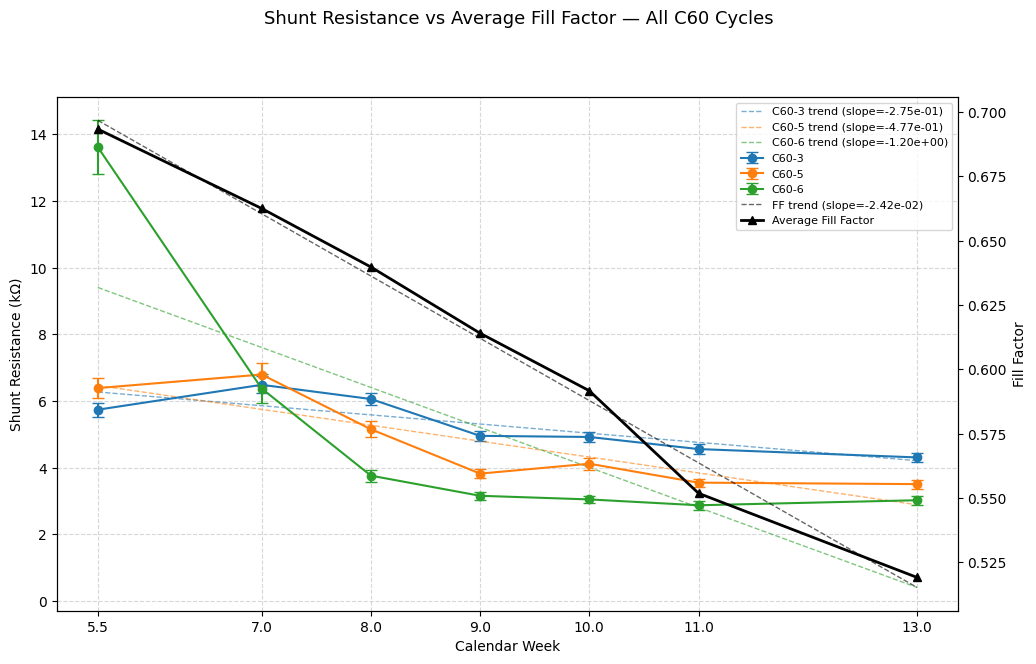

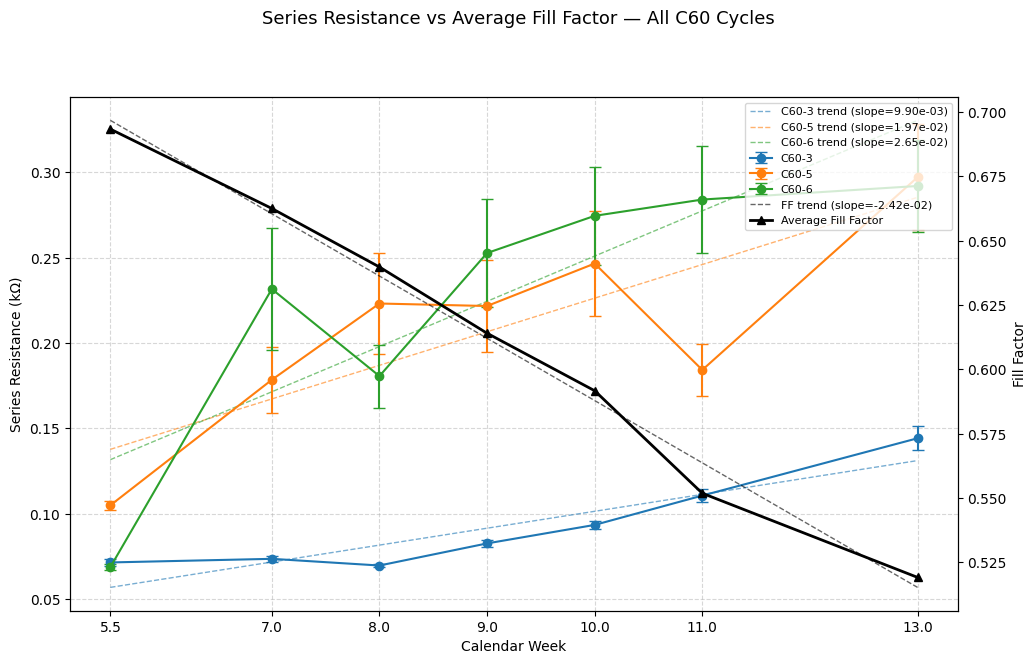

In [22]:
# ============================================================
# FUNCTION — plot_combined_summary
# ============================================================

def plot_combined_summary(results, ff_results, num_weeks):
    """
    Produces two graphs — one for shunt resistance and one for
    series resistance — each showing all three C60 cycles on the
    same plot alongside a single averaged fill factor reference
    line. Left y-axis shows resistance (kΩ), right y-axis
    shows fill factor. Trend lines included for all variables.

    Parameters:
        results    : resistance results dict
        ff_results : fill factor results dict
        num_weeks  : total number of weeks (int)
    """

    week_numbers = [5.5, 7, 8, 9, 10, 11, 13]

    cycle_styles = {
        3: {"color": "tab:blue",   "label": "C60-3"},
        5: {"color": "tab:orange", "label": "C60-5"},
        6: {"color": "tab:green",  "label": "C60-6"},
    }

    configs = [
          {
              "res_idx"   : 0,
              "sem_idx"   : 2,
              "count_idx" : 4,
              "ylabel"    : "Shunt Resistance (kΩ)",
              "title"     : "Shunt Resistance vs Average Fill Factor — All C60 Cycles",
          },
          {
              "res_idx"   : 1,
              "sem_idx"   : 3,
              "count_idx" : 5,
              "ylabel"    : "Series Resistance (kΩ)",
              "title"     : "Series Resistance vs Average Fill Factor — All C60 Cycles",
          },
      ]

    # Compute averaged fill factor across all three cycles
    ff_avg_line = []
    ff_avg_sems = []
    for week_idx in range(num_weeks):
        vals = []
        for cycle in [3, 5, 6]:
            if week_idx in ff_results[cycle]:
                vals.append(ff_results[cycle][week_idx][0])
        ff_avg_line.append(np.mean(vals) if vals else np.nan)
        ff_avg_sems.append(np.nan)

    # Trend line for averaged FF
    def get_trend(avgs):
        valid = [(w, a) for w, a in zip(week_numbers, avgs) if not np.isnan(a)]
        if len(valid) < 2:
            return [np.nan] * len(week_numbers), np.nan
        wx, wy = zip(*valid)
        slope, intercept = np.polyfit(wx, wy, 1)
        return [slope * w + intercept for w in week_numbers], slope

    ff_avg_trend, ff_avg_slope = get_trend(ff_avg_line)

    for config in configs:

        fig, ax1 = plt.subplots(figsize=(11, 7))
        fig.suptitle(config["title"], fontsize=13)

        # Left axis — resistance per cycle
        for cycle, style in cycle_styles.items():
            res_avgs = []
            res_sems = []
            for week_idx in range(num_weeks):
                if week_idx in results[cycle]:
                    count = results[cycle][week_idx][config["count_idx"]]
                    res_avgs.append(results[cycle][week_idx][config["res_idx"]])
                    res_sems.append(results[cycle][week_idx][config["sem_idx"]] / np.sqrt(count))
                else:
                    res_avgs.append(np.nan)
                    res_sems.append(np.nan)

            res_trend, res_slope = get_trend(res_avgs)

            ax1.errorbar(
                week_numbers, res_avgs, yerr=res_sems,
                color=style["color"], marker="o",
                capsize=4, linewidth=1.5,
                label=style["label"],
            )
            ax1.plot(
                week_numbers, res_trend,
                color=style["color"], linewidth=1,
                linestyle="--", alpha=0.6,
                label=f"{style['label']} trend (slope={res_slope:.2e})",
            )

        ax1.set_ylabel(config["ylabel"])
        ax1.set_xlabel("Calendar Week")
        ax1.set_xticks(week_numbers)
        ax1.grid(True, linestyle="--", alpha=0.5)

        # Right axis — averaged fill factor reference line
        ax2 = ax1.twinx()
        ax2.errorbar(
            week_numbers, ff_avg_line,
            color="black", marker="^",
            capsize=4, linewidth=2,
            linestyle="-", label="Average Fill Factor",
        )
        ax2.plot(
            week_numbers, ff_avg_trend,
            color="black", linewidth=1,
            linestyle="--", alpha=0.6,
            label=f"FF trend (slope={ff_avg_slope:.2e})",
        )
        ax2.set_ylabel("Fill Factor")
        ax2.tick_params(axis="y")

        # Combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc="upper right", fontsize=8,
        )

        plt.tight_layout(pad=3.0)
        plt.show()

plot_combined_summary(results, ff_results, num_weeks)